# 🔥 Fire & Smoke Object Detection — Deep Learning Project

**Author:** Senior Computer Vision Engineer / Deep Learning Researcher
**Task:** Real-time Fire Detection via Object Detection (YOLOv8n / YOLOv8s / YOLOv8m)
**Framework:** Ultralytics YOLOv8, PyTorch

---

## ⚠️ How to use this notebook

1. This notebook is a **complete, production-ready template**.
2. The dataset is **not required to build or open this notebook** — every cell is guarded so the notebook runs safely even without data.
3. Once you have a Roboflow-exported object-detection dataset (CSV format, `filename,width,height,class,xmin,ymin,xmax,ymax`), simply:
   - Place it on disk in the structure described below.
   - Update **only** the `DATASET_PATH` variable in the *Configuration* cell.
4. Re-run the notebook top-to-bottom. No other code needs to change.

### Expected dataset structure
```
dataset/
├── train/
│   ├── _annotations.csv
│   ├── images...
├── valid/
│   ├── _annotations.csv
│   ├── images...
├── test/
│   ├── _annotations.csv
│   ├── images...
```


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Part 1 — Imports & Configuration

This section imports every library used throughout the notebook, detects the available
hardware (GPU/CPU), fixes random seeds for reproducibility, and defines **all path
variables** used by the rest of the notebook. This is the **only** place you need to
edit once the dataset is available — update `DATASET_PATH` and everything downstream
adapts automatically.


In [2]:
!unzip fire.v2i.tensorflow.zip -d /content/fire_dataset

In [3]:
!ls /content/fire_dataset

In [4]:
!pip install ultralytics -q

[notice] A new release of pip available: 22.3 -> 26.2.1


In [5]:
%pip install seaborn


[notice] A new release of pip available: 22.3 -> 26.2.1


In [6]:
import os

# Define your directory path here (replace with your actual folder path)
DATASET_PATH = "./"  # '.' stands for the current working directory

print(os.listdir(DATASET_PATH))

['.venv', 'data.yaml', 'data_fixed.yaml', 'fire_detection_project', 'Fire_Detection_YOLOv8_RFDETR_FasterRCNN_SSD_Project (1).ipynb', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid', 'yolov8m.pt', 'yolov8n.pt', 'yolov8s.pt']


In [7]:
!pip install opencv-python

[notice] A new release of pip available: 22.3 -> 26.2.1


In [8]:
!pip install opencv-python

[notice] A new release of pip available: 22.3 -> 26.2.1


In [9]:
!pip install opencv-python-headless

[notice] A new release of pip available: 22.3 -> 26.2.1


In [10]:
pip install opencv-python

[notice] A new release of pip available: 22.3 -> 26.2.1


In [11]:
%pip install opencv-python

[notice] A new release of pip available: 22.3 -> 26.2.1


In [12]:
import sys
!{sys.executable} -m pip install opencv-python

[notice] A new release of pip available: 22.3 -> 26.2.1


In [13]:
%pip install opencv-python-headless

[notice] A new release of pip available: 22.3 -> 26.2.1


In [14]:
try:
    import cv2
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python"])
    import cv2

In [15]:
# ------------------------------------------------------------------
# Core / standard library
# ------------------------------------------------------------------
import os
import sys
import gc
import json
import glob
import shutil
import random
import time
import warnings
import platform
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Data / numerical
# ------------------------------------------------------------------
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------
import matplotlib
 # safe backend for headless / notebook execution
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as patches
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

# ------------------------------------------------------------------
# Image processing
# ------------------------------------------------------------------
import cv2  # This should now import without issues!
from PIL import Image, ImageOps

# ------------------------------------------------------------------
# Deep Learning
# ------------------------------------------------------------------
import torch

try:
    import tensorflow as tf
    TF_AVAILABLE = True
except Exception:
    TF_AVAILABLE = False

try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except Exception:
    ULTRALYTICS_AVAILABLE = False
    print("[WARNING] 'ultralytics' package not found. Install it with: pip install ultralytics")

try:
    import yaml
except Exception:
    os.system(f"{sys.executable} -m pip install pyyaml -q")
    import yaml

print("=" * 70)
print("ENVIRONMENT INFORMATION")
print("=" * 70)
print(f"Python version      : {platform.python_version()}")
print(f"PyTorch version      : {torch.__version__}")
print(f"TensorFlow version   : {tf.__version__ if TF_AVAILABLE else 'not installed'}")
print(f"Ultralytics installed: {ULTRALYTICS_AVAILABLE}")

CUDA_AVAILABLE = torch.cuda.is_available()
print(f"CUDA available       : {CUDA_AVAILABLE}")
if CUDA_AVAILABLE:
    print(f"GPU device           : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version         : {torch.version.cuda}")
else:
    print("GPU device           : None (training will fall back to CPU — this will be slow)")

DEVICE = "0" if CUDA_AVAILABLE else "cpu"
print(f"Selected device      : {DEVICE}")
print("=" * 70)


ENVIRONMENT INFORMATION
Python version      : 3.11.0
PyTorch version      : 2.4.1+cu121
TensorFlow version   : not installed
Ultralytics installed: True
CUDA available       : True
GPU device           : NVIDIA RTX 2000 Ada Generation
CUDA version         : 12.1
Selected device      : 0


In [16]:
# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
SEED = 42

def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility across libraries."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed fixed to {SEED}")


Random seed fixed to 42


In [18]:
# ==============================================================================
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>  DATASET CONFIGURATION  <<<<<<<<<<<<<<<<<<<<<<<<<
# ==============================================================================
# This is the ONLY cell you need to edit once the dataset is available.
# Replace the string below with the absolute or relative path to your dataset root.
# Every other cell in this notebook derives its paths from this single variable.
# ==============================================================================

DATASET_PATH = r"C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8"   # <-- EDIT THIS LINE ONLY  # <-- EDIT THIS LINE ONLY

# ------------------------------------------------------------------
# Derived paths (do NOT edit — these are built automatically)
# ------------------------------------------------------------------
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VALID_PATH = os.path.join(DATASET_PATH, "valid")
TEST_PATH  = os.path.join(DATASET_PATH, "test")

TRAIN_CSV = os.path.join(TRAIN_PATH, "_annotations.csv")
VALID_CSV = os.path.join(VALID_PATH, "_annotations.csv")
TEST_CSV  = os.path.join(TEST_PATH,  "_annotations.csv")

# ------------------------------------------------------------------
# Project working directories (created automatically, independent of dataset)
# ------------------------------------------------------------------
PROJECT_ROOT   = os.path.abspath("fire_detection_project")
YOLO_DATA_DIR  = os.path.join(PROJECT_ROOT, "yolo_dataset")
FIGURES_DIR    = os.path.join(PROJECT_ROOT, "figures")
MODELS_DIR     = os.path.join(PROJECT_ROOT, "models")
RUNS_DIR       = os.path.join(PROJECT_ROOT, "runs")
REPORTS_DIR    = os.path.join(PROJECT_ROOT, "reports")
PREDICTIONS_DIR = os.path.join(PROJECT_ROOT, "predictions")
LOGS_DIR       = os.path.join(PROJECT_ROOT, "logs")

for d in [PROJECT_ROOT, YOLO_DATA_DIR, FIGURES_DIR, MODELS_DIR, RUNS_DIR,
          REPORTS_DIR, PREDICTIONS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

DATASET_YAML_PATH = os.path.join(YOLO_DATA_DIR, "dataset.yaml")
COMPARISON_CSV_PATH = os.path.join(REPORTS_DIR, "comparison.csv")
METRICS_CSV_PATH = os.path.join(REPORTS_DIR, "metrics.csv")
FINAL_REPORT_PATH = os.path.join(REPORTS_DIR, "final_report.md")

def dataset_is_ready() -> bool:
    """Returns True if the dataset path exists and contains data.yaml or train folder."""
    if DATASET_PATH == "YOUR_DATASET_PATH" or not os.path.isdir(DATASET_PATH):
        return False
    has_yaml = os.path.isfile(os.path.join(DATASET_PATH, "data.yaml"))
    has_folders = os.path.exists(TRAIN_PATH) and os.path.exists(VALID_PATH)
    return has_yaml or has_folders

DATASET_READY = dataset_is_ready()

print("Project directories created under:", PROJECT_ROOT)
print("-" * 70)
if DATASET_READY:
    print(f"[OK] Dataset detected at: {DATASET_PATH}")
else:
    print("[INFO] Dataset not found yet.")
    print(f"       Please update DATASET_PATH (currently: '{DATASET_PATH}').")
    print("       All subsequent cells are safe to run — they will skip heavy")
    print("       computation and show informative messages until the dataset exists.")
print("-" * 70)


Project directories created under: c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project
----------------------------------------------------------------------
[OK] Dataset detected at: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8
----------------------------------------------------------------------


## Part 2 — Dataset Inspection

Before doing any analysis, we validate the dataset's structural integrity:
counting images/classes/boxes, detecting missing or corrupted images, duplicate
annotations, and empty folders. Everything below is guarded — if the dataset is not
yet present, a clear message is printed and **no code crashes**.


In [19]:
def load_annotations(csv_path: str) -> pd.DataFrame:
    """Safely load a Roboflow-style annotation CSV. Returns empty DataFrame if missing."""
    expected_cols = ["filename", "width", "height", "class", "xmin", "ymin", "xmax", "ymax"]
    if not os.path.isfile(csv_path):
        return pd.DataFrame(columns=expected_cols)
    try:
        df = pd.read_csv(csv_path)
        missing_cols = [c for c in expected_cols if c not in df.columns]
        if missing_cols:
            print(f"[WARNING] {csv_path} is missing expected columns: {missing_cols}")
        return df
    except Exception as e:
        print(f"[ERROR] Failed to read {csv_path}: {e}")
        return pd.DataFrame(columns=expected_cols)


def check_missing_images(df: pd.DataFrame, images_dir: str) -> list:
    """Return list of filenames referenced in annotations but not found on disk."""
    if df.empty or not os.path.isdir(images_dir):
        return []
    missing = [f for f in df["filename"].unique() if not os.path.isfile(os.path.join(images_dir, f))]
    return missing


def check_corrupted_images(images_dir: str) -> list:
    """Attempt to open every image in a folder; return list of files that fail to load."""
    corrupted = []
    if not os.path.isdir(images_dir):
        return corrupted
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp")
    for fname in os.listdir(images_dir):
        if not fname.lower().endswith(valid_ext):
            continue
        fpath = os.path.join(images_dir, fname)
        try:
            with Image.open(fpath) as im:
                im.verify()
        except Exception:
            corrupted.append(fname)
    return corrupted


def check_duplicate_annotations(df: pd.DataFrame) -> int:
    """Count fully duplicated annotation rows."""
    if df.empty:
        return 0
    return int(df.duplicated(subset=["filename", "class", "xmin", "ymin", "xmax", "ymax"]).sum())


def check_empty_folder(folder: str) -> bool:
    """Return True if the folder does not exist or contains no files."""
    if not os.path.isdir(folder):
        return True
    return len(os.listdir(folder)) == 0


def inspect_split(name: str, csv_path: str, images_dir: str) -> dict:
    """Run the full battery of integrity checks on a single dataset split."""
    df = load_annotations(csv_path)
    result = {
        "split": name,
        "csv_exists": os.path.isfile(csv_path),
        "num_images": df["filename"].nunique() if not df.empty else 0,
        "num_boxes": len(df),
        "num_classes": df["class"].nunique() if not df.empty else 0,
        "classes": sorted(df["class"].unique().tolist()) if not df.empty else [],
        "missing_images": check_missing_images(df, images_dir),
        "corrupted_images": check_corrupted_images(images_dir),
        "duplicate_annotations": check_duplicate_annotations(df),
        "empty_folder": check_empty_folder(images_dir),
    }
    return result, df


print("=" * 70)
print("DATASET INSPECTION")
print("=" * 70)

if not DATASET_READY:
    print("[INFO] Dataset not available yet.")
    print(f"       Update DATASET_PATH at the top of the notebook (currently: '{DATASET_PATH}').")
    print("       Expected structure:")
    print("         dataset/train/_annotations.csv + images")
    print("         dataset/valid/_annotations.csv + images")
    print("         dataset/test/_annotations.csv  + images")
    train_df, valid_df, test_df = (pd.DataFrame(), pd.DataFrame(), pd.DataFrame())
    inspection_results = []
else:
    splits = [
        ("train", TRAIN_CSV, TRAIN_PATH),
        ("valid", VALID_CSV, VALID_PATH),
        ("test",  TEST_CSV,  TEST_PATH),
    ]
    inspection_results = []
    dfs = {}
    for split_name, csv_path, images_dir in splits:
        result, df = inspect_split(split_name, csv_path, images_dir)
        inspection_results.append(result)
        dfs[split_name] = df

    train_df, valid_df, test_df = dfs["train"], dfs["valid"], dfs["test"]

    summary_table = pd.DataFrame([{
        "Split": r["split"],
        "Images": r["num_images"],
        "Boxes": r["num_boxes"],
        "Classes": r["num_classes"],
        "Missing Images": len(r["missing_images"]),
        "Corrupted Images": len(r["corrupted_images"]),
        "Duplicate Annotations": r["duplicate_annotations"],
        "Empty Folder": r["empty_folder"],
    } for r in inspection_results])

    print(summary_table.to_string(index=False))
    print("-" * 70)
    all_classes = sorted(set().union(*[set(r["classes"]) for r in inspection_results])) if inspection_results else []
    print(f"Detected classes across all splits: {all_classes}")

    for r in inspection_results:
        if r["missing_images"]:
            print(f"[WARNING] {r['split']}: {len(r['missing_images'])} referenced images not found on disk.")
        if r["corrupted_images"]:
            print(f"[WARNING] {r['split']}: {len(r['corrupted_images'])} corrupted/unreadable images.")
        if r["duplicate_annotations"]:
            print(f"[WARNING] {r['split']}: {r['duplicate_annotations']} duplicate annotation rows.")


DATASET INSPECTION
Split  Images  Boxes  Classes  Missing Images  Corrupted Images  Duplicate Annotations  Empty Folder
train       0      0        0               0                 0                      0         False
valid       0      0        0               0                 0                      0         False
 test       0      0        0               0                 0                      0         False
----------------------------------------------------------------------
Detected classes across all splits: []


## Part 3 — Exploratory Data Analysis (EDA)

Every figure below is computed **dynamically** from the real annotation data — nothing
is hard-coded or faked. If the dataset is not present, each function simply reports
that there is no data to visualize and moves on without crashing. Every figure is also
saved as a PNG file inside `figures/` for inclusion in the final report.


In [20]:
from pathlib import Path

# Use current working directory as the dataset path
dataset_path = Path(".") 

# Inspect dataset structure
for split in ["train", "valid", "test"]:
    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    image_count = len(list(image_dir.glob("*"))) if image_dir.exists() else 0
    label_count = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0

    print(f"{split.upper()}")
    print("-" * 30)
    print(f"Images : {image_count}")
    print(f"Labels : {label_count}")

    if image_count == label_count and image_count > 0:
        print("Status : ✅ Images and labels match.\n")
    else:
        print("Status : ❌ Images and labels do NOT match.\n")

TRAIN
------------------------------
Images : 7407
Labels : 7407
Status : ✅ Images and labels match.

VALID
------------------------------
Images : 702
Labels : 702
Status : ✅ Images and labels match.

TEST
------------------------------
Images : 347
Labels : 347
Status : ✅ Images and labels match.


In [21]:
from pathlib import Path

# Set local Windows path where the dataset was extracted
extract_path = r"C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8"
dataset_path = Path(extract_path)

# Dataset sections
splits = ["train", "valid", "test"]

# Common image extensions
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in splits:
    print("=" * 55)
    print(f"{split.upper()} SPLIT")
    print("=" * 55)

    # Define the image and label folder paths
    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    # Check whether the required folders exist
    if not image_dir.exists():
        print(f"❌ Images folder not found: {image_dir}\n")
        continue

    if not label_dir.exists():
        print(f"❌ Labels folder not found: {label_dir}\n")
        continue

    # Collect valid image files only
    image_files = [
        file
        for file in image_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    # Collect TXT label files only
    label_files = [
        file
        for file in label_dir.iterdir()
        if file.is_file() and file.suffix.lower() == ".txt"
    ]

    # Extract file names without extensions
    image_names = {file.stem for file in image_files}
    label_names = {file.stem for file in label_files}

    # Find unmatched files
    images_without_labels = image_names - label_names
    labels_without_images = label_names - image_names

    # Display the results
    print(f"Images folder: {image_dir}")
    print(f"Labels folder: {label_dir}")
    print(f"Number of images: {len(image_files)}")
    print(f"Number of labels: {len(label_files)}")
    print(f"Images without labels: {len(images_without_labels)}")
    print(f"Labels without images: {len(labels_without_images)}")

    if not images_without_labels and not labels_without_images:
        print("Status: ✅ All images and labels are correctly matched.\n")
    else:
        print("Status: ⚠️ Some files are not correctly matched.\n")

        if images_without_labels:
            print("Examples of images without labels:")
            print(list(sorted(images_without_labels))[:5])

        if labels_without_images:
            print("Examples of labels without images:")
            print(list(sorted(labels_without_images))[:5])

        print()

TRAIN SPLIT
Images folder: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8\train\images
Labels folder: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8\train\labels
Number of images: 7407
Number of labels: 7407
Images without labels: 0
Labels without images: 0
Status: ✅ All images and labels are correctly matched.

VALID SPLIT
Images folder: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8\valid\images
Labels folder: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8\valid\labels
Number of images: 702
Number of labels: 702
Images without labels: 0
Labels without images: 0
Status: ✅ All images and labels are correctly matched.

TEST SPLIT
Images folder: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8\test\images
Labels folder: C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8\test\labels
Number of images: 347
Number of labels: 347
Images without labels: 0
Labels without images: 0
Status: ✅ All image

In [22]:
# ==========================================
# Step 3: Visualize One Annotated Image
# ==========================================

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
from PIL import Image

# Use current working directory as the dataset path
dataset_path = Path(".")

# Path to the YAML configuration file
yaml_path = dataset_path / "data.yaml"


# ------------------------------------------
# 1. Read the data.yaml file
# ------------------------------------------

if not yaml_path.exists():
    raise FileNotFoundError(f"data.yaml not found at: {yaml_path.resolve()}")

with open(yaml_path, "r", encoding="utf-8") as yaml_file:
    dataset_config = yaml.safe_load(yaml_file)

class_names = dataset_config["names"]
number_of_classes = dataset_config.get("nc", len(class_names))

print("Number of classes:", number_of_classes)
print("Class names:", class_names)


# ------------------------------------------
# 2. Select one image from the test split
# ------------------------------------------

image_dir = dataset_path / "test" / "images"
label_dir = dataset_path / "test" / "labels"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = sorted(
    [
        file
        for file in image_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]
)

if not image_files:
    raise FileNotFoundError(
        f"No image files were found inside: {image_dir.resolve()}"
    )

selected_image_path = image_files[0]
selected_label_path = label_dir / f"{selected_image_path.stem}.txt"

if not selected_label_path.exists():
    raise FileNotFoundError(
        f"No matching label file was found for: {selected_image_path.name}"
    )


# ------------------------------------------
# 3. Open the image
# ------------------------------------------

image = Image.open(selected_image_path).convert("RGB")
image_width, image_height = image.size

print("\nSelected image:", selected_image_path.name)
print("Matching label:", selected_label_path.name)
print("Image width:", image_width)
print("Image height:", image_height)


# ------------------------------------------
# 4. Read the YOLO annotation file
# ------------------------------------------

annotations = []

with open(selected_label_path, "r", encoding="utf-8") as label_file:
    for line_number, line in enumerate(label_file, start=1):
        values = line.strip().split()

        if not values:
            continue

        if len(values) != 5:
            print(
                f"Warning: Line {line_number} does not contain "
                "exactly five values."
            )
            continue

        class_id = int(values[0])
        x_center = float(values[1])
        y_center = float(values[2])
        box_width = float(values[3])
        box_height = float(values[4])

        annotations.append(
            {
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": box_width,
                "height": box_height,
            }
        )

print("Number of objects in the image:", len(annotations))


# ------------------------------------------
# 5. Display the image and bounding boxes
# ------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(image)

for annotation in annotations:
    class_id = annotation["class_id"]

    # Convert normalized YOLO values into pixel values
    box_width_pixels = annotation["width"] * image_width
    box_height_pixels = annotation["height"] * image_height

    x_center_pixels = annotation["x_center"] * image_width
    y_center_pixels = annotation["y_center"] * image_height

    # Convert center coordinates into top-left corner coordinates
    x_min = x_center_pixels - (box_width_pixels / 2)
    y_min = y_center_pixels - (box_height_pixels / 2)

    rectangle = patches.Rectangle(
        (x_min, y_min),
        box_width_pixels,
        box_height_pixels,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )

    ax.add_patch(rectangle)

    # Get string class name whether YAML names is a dict or a list
    if isinstance(class_names, dict):
        class_name = class_names.get(class_id, class_id)
    else:
        class_name = class_names[class_id]

    ax.text(
        x_min,
        max(y_min - 5, 0),
        str(class_name),
        fontsize=11,
        bbox={
            "facecolor": "white",
            "alpha": 0.8,
            "edgecolor": "none",
        },
    )

ax.set_title(
    f"Annotated Image: {selected_image_path.name}",
    fontsize=14,
)

ax.axis("off")

plt.tight_layout()
plt.show()

Number of classes: 2
Class names: ['fire', 'smoke']

Selected image: 0072_JPG_jpg.rf.20f5b46815080c492db73508a9d44665.jpg
Matching label: 0072_JPG_jpg.rf.20f5b46815080c492db73508a9d44665.txt
Image width: 640
Image height: 640
Number of objects in the image: 3


,Class,Object Count
0,fire,12565
1,smoke,2803


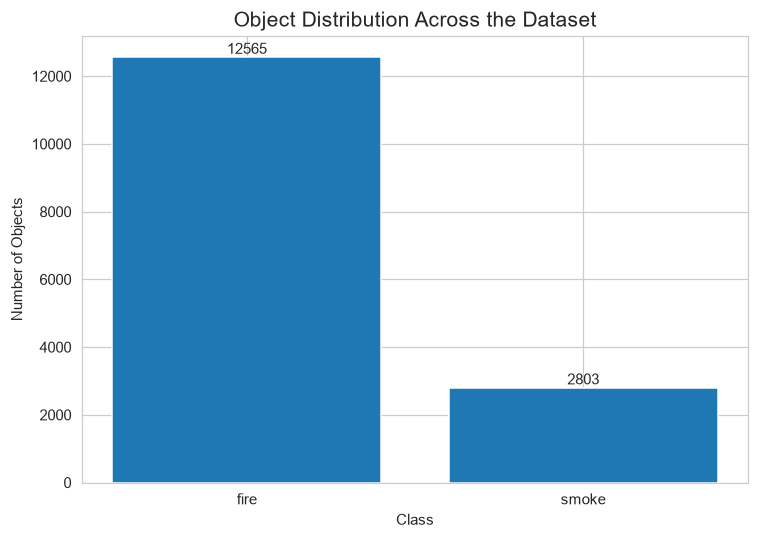

In [23]:
# ==========================================
# Step 4: Class Distribution Analysis
# ==========================================

from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Use relative path to point to your current workspace root
dataset_path = Path(".")

# Load YAML if dataset_config isn't already defined
yaml_path = dataset_path / "data.yaml"
if "dataset_config" not in globals() and yaml_path.exists():
    with open(yaml_path, "r", encoding="utf-8") as file:
        dataset_config = yaml.safe_load(file)

# Read class names
class_names = dataset_config["names"]

# Counter for all classes
class_counter = Counter()

# Scan all dataset splits
for split in ["train", "valid", "test"]:
    label_folder = dataset_path / split / "labels"

    if not label_folder.exists():
        continue

    for label_file in label_folder.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as file:
            for line in file:
                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id = int(values[0])

                # Safe class name extraction
                if isinstance(class_names, dict):
                    c_name = class_names.get(class_id, class_names.get(str(class_id), f"Class {class_id}"))
                else:
                    c_name = class_names[class_id]

                class_counter[c_name] += 1

# Convert to DataFrame
class_distribution = pd.DataFrame(
    {
        "Class": list(class_counter.keys()),
        "Object Count": list(class_counter.values()),
    }
)

# Sort descending
class_distribution = class_distribution.sort_values(
    by="Object Count",
    ascending=False
).reset_index(drop=True)

display(class_distribution)

# Plot
if not class_distribution.empty:
    plt.figure(figsize=(7, 5))

    bars = plt.bar(
        class_distribution["Class"],
        class_distribution["Object Count"]
    )

    plt.title("Object Distribution Across the Dataset", fontsize=14)
    plt.xlabel("Class")
    plt.ylabel("Number of Objects")

    # Add values above bars
    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No objects found! Please check if the labels folder contains .txt files.")

In [24]:
# Calculate percentages
total_objects = class_distribution["Object Count"].sum()

class_distribution["Percentage"] = (
    class_distribution["Object Count"] / total_objects * 100
).round(2)

display(class_distribution)

,Class,Object Count,Percentage
0,fire,12565,81.76
1,smoke,2803,18.24


In [25]:
# ==========================================
# Step 5: Image Properties Analysis
# ==========================================

from pathlib import Path
from collections import Counter

from PIL import Image
import pandas as pd

# Use current working directory as the dataset path
dataset_path = Path(".")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_information = []
corrupted_images = []

for split in ["train", "valid", "test"]:

    image_folder = dataset_path / split / "images"

    if not image_folder.exists():
        print(f"⚠️ Directory not found: {image_folder.resolve()}")
        continue

    for image_file in image_folder.iterdir():

        if not image_file.is_file() or image_file.suffix.lower() not in image_extensions:
            continue

        try:

            with Image.open(image_file) as img:

                width, height = img.size

                image_information.append({
                    "Split": split,
                    "File Name": image_file.name,
                    "Width": width,
                    "Height": height,
                    "Mode": img.mode,
                    "Format": img.format
                })

        except Exception:

            corrupted_images.append(image_file.name)

# Convert to DataFrame
if image_information:
    image_df = pd.DataFrame(image_information)

    print("=" * 60)
    print("Dataset Image Summary")
    print("=" * 60)

    print(f"Total images      : {len(image_df)}")
    print(f"Corrupted images  : {len(corrupted_images)}")

    print("\nImage Modes:")
    display(image_df["Mode"].value_counts())

    print("\nImage Formats:")
    display(image_df["Format"].value_counts())

    print("\nMost Common Image Sizes:")
    display(
        image_df[["Width", "Height"]]
        .value_counts()
        .head(10)
    )

    print("\nSummary Statistics:")
    display(
        image_df[["Width", "Height"]]
        .describe()
    )
else:
    print("❌ No images found! Check the path again.")

Dataset Image Summary
Total images      : 8456
Corrupted images  : 0

Image Modes:


Mode
RGB    8456
Name: count, dtype: int64

Image Formats:


Format
JPEG    8456
Name: count, dtype: int64

Most Common Image Sizes:


Width  Height
640    640       8456
Name: count, dtype: int64

Summary Statistics:


,Width,Height
count,8456.0,8456.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


Objects Per Image Summary


,Split,Image,Object Count
0,train,0050_jpg.rf.4e03b70ab97e60c7fede569be2942ed9,1
1,train,0050_jpg.rf.d26a43c1bae75de2882b94da4e9b3510,1
2,train,0050_jpg.rf.e8b54db77ff3417734d86ad07bdbc481,1
3,train,0055_jpg.rf.2286b2e289e83f768f1db192a669c573,3
4,train,0055_jpg.rf.baf7fb3bbfdacb5cd3b7d10e5336fb9c,3


Summary Statistics:


count    8456.000000
mean        1.817408
std         1.687540
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: Object Count, dtype: float64

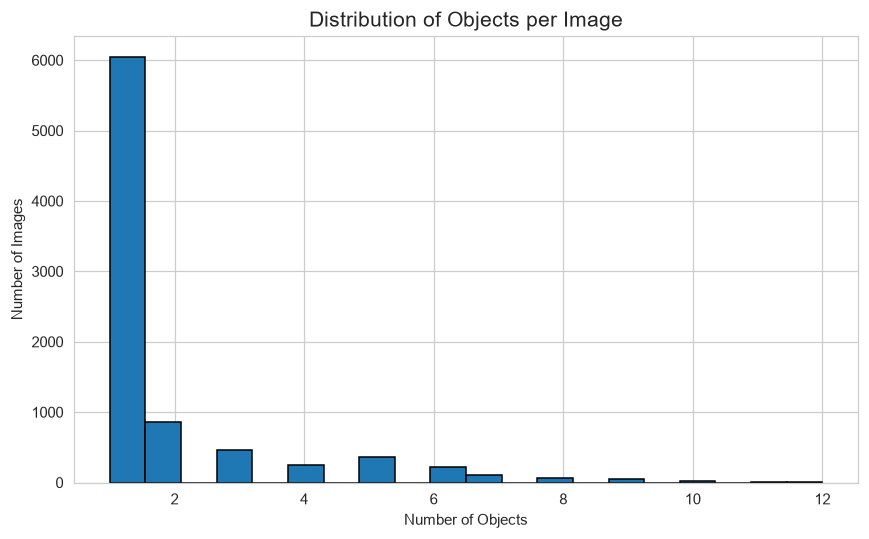

In [26]:
# ==========================================
# Step 6: Objects Per Image Analysis
# ==========================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Use current working directory as the dataset path
dataset_path = Path(".")

records = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    if not label_folder.exists():
        continue

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r", encoding="utf-8") as file:

            object_count = 0

            for line in file:

                if len(line.strip().split()) == 5:
                    object_count += 1

            records.append({
                "Split": split,
                "Image": label_file.stem,
                "Object Count": object_count
            })

# Convert to DataFrame
if records:
    objects_df = pd.DataFrame(records)

    print("=" * 60)
    print("Objects Per Image Summary")
    print("=" * 60)

    display(objects_df.head())

    print("\nSummary Statistics:")
    display(objects_df["Object Count"].describe())

    # Plot Histogram
    plt.figure(figsize=(8, 5))

    plt.hist(
        objects_df["Object Count"],
        bins=20,
        edgecolor="black"
    )

    plt.title("Distribution of Objects per Image", fontsize=14)
    plt.xlabel("Number of Objects")
    plt.ylabel("Number of Images")

    plt.tight_layout()
    plt.show()
else:
    print("❌ No labels found! Please check the dataset path.")

Bounding Box Summary


,Split,Class ID,Width,Height,Area
0,train,0,0.264062,0.181250,0.047861
1,train,0,0.276847,0.198494,0.054952
2,train,0,0.282382,0.212881,0.060114
3,train,1,0.113011,0.318232,0.035964
4,train,0,0.179273,0.376359,0.067471


Summary Statistics:


,Width,Height,Area
count,15368.000000,15368.000000,15368.000000
mean,0.296352,0.305494,0.124702
std,0.261408,0.241673,0.174558
min,0.002644,0.006250,0.000088
25%,0.092893,0.110937,0.009911
50%,0.204108,0.218750,0.055105
75%,0.417178,0.438888,0.168810
max,1.000000,1.000000,1.000000


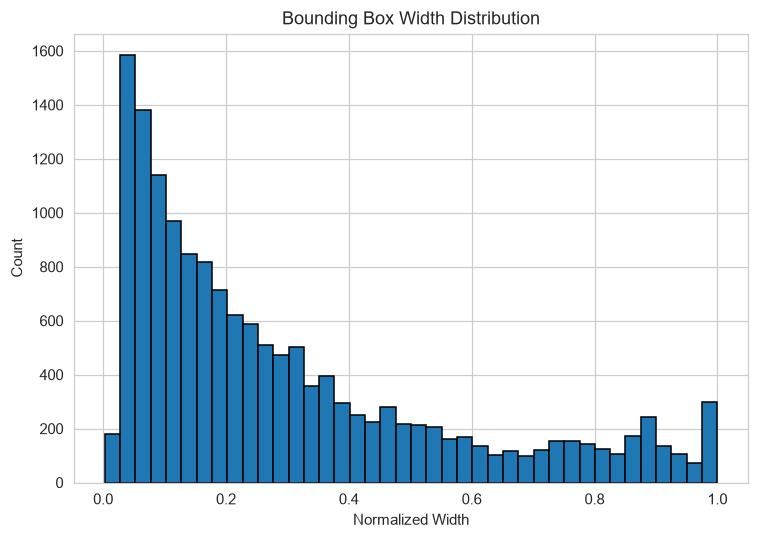

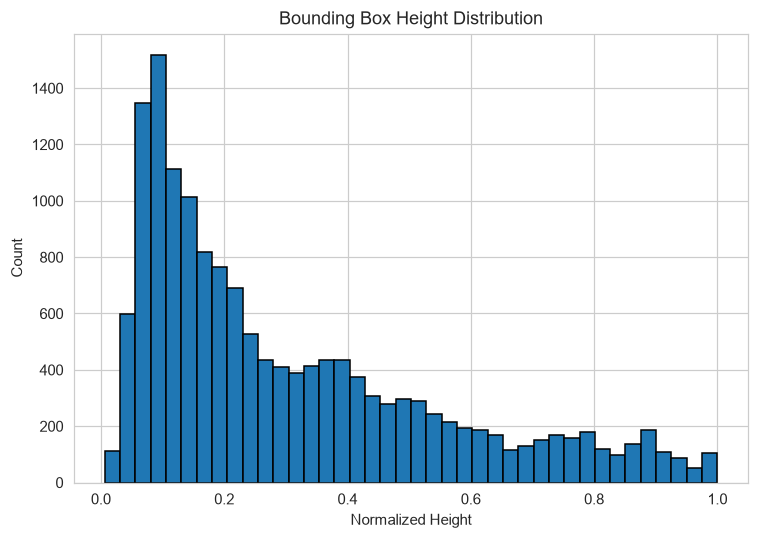

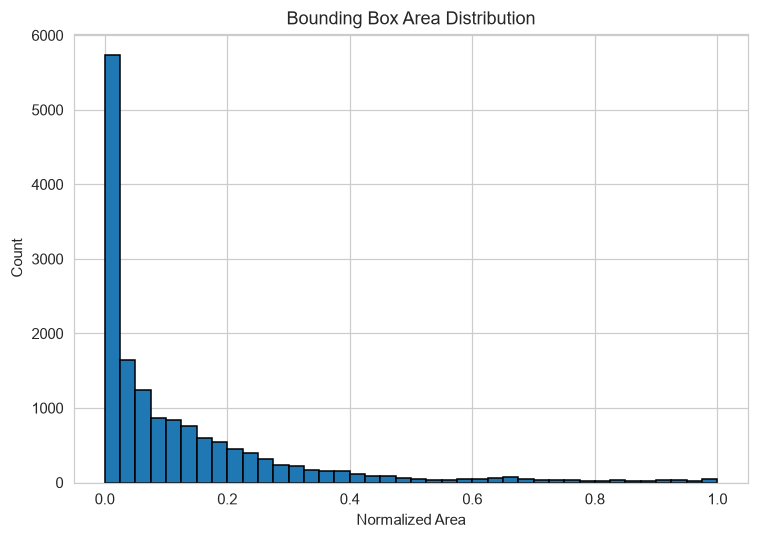

In [27]:
# ==========================================
# Step 7: Bounding Box Size Analysis
# ==========================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Use current working directory as the dataset path
dataset_path = Path(".")

bounding_boxes = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    if not label_folder.exists():
        continue

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r", encoding="utf-8") as file:

            for line in file:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id = int(values[0])

                width = float(values[3])
                height = float(values[4])

                area = width * height

                bounding_boxes.append({
                    "Split": split,
                    "Class ID": class_id,
                    "Width": width,
                    "Height": height,
                    "Area": area
                })

# Convert to DataFrame
bbox_df = pd.DataFrame(bounding_boxes)

print("=" * 60)
print("Bounding Box Summary")
print("=" * 60)

if not bbox_df.empty:
    display(bbox_df.head())

    print("\nSummary Statistics:")
    display(
        bbox_df[["Width", "Height", "Area"]].describe()
    )

    # Plot Width Distribution
    plt.figure(figsize=(7, 5))

    plt.hist(
        bbox_df["Width"],
        bins=40,
        edgecolor="black"
    )

    plt.title("Bounding Box Width Distribution")
    plt.xlabel("Normalized Width")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    # Plot Height Distribution
    plt.figure(figsize=(7, 5))

    plt.hist(
        bbox_df["Height"],
        bins=40,
        edgecolor="black"
    )

    plt.title("Bounding Box Height Distribution")
    plt.xlabel("Normalized Height")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    # Plot Area Distribution
    plt.figure(figsize=(7, 5))

    plt.hist(
        bbox_df["Area"],
        bins=40,
        edgecolor="black"
    )

    plt.title("Bounding Box Area Distribution")
    plt.xlabel("Normalized Area")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("❌ No bounding box data found! Please check the dataset path.")

Bounding Box Center Summary


,Class ID,X Center,Y Center
count,15368.000000,15368.000000,15368.000000
mean,0.182392,0.487424,0.510922
std,0.386180,0.181805,0.205889
min,0.000000,0.001322,0.024219
25%,0.000000,0.386061,0.375304
50%,0.000000,0.480469,0.500781
75%,0.000000,0.583594,0.650077
max,1.000000,0.994960,0.980469


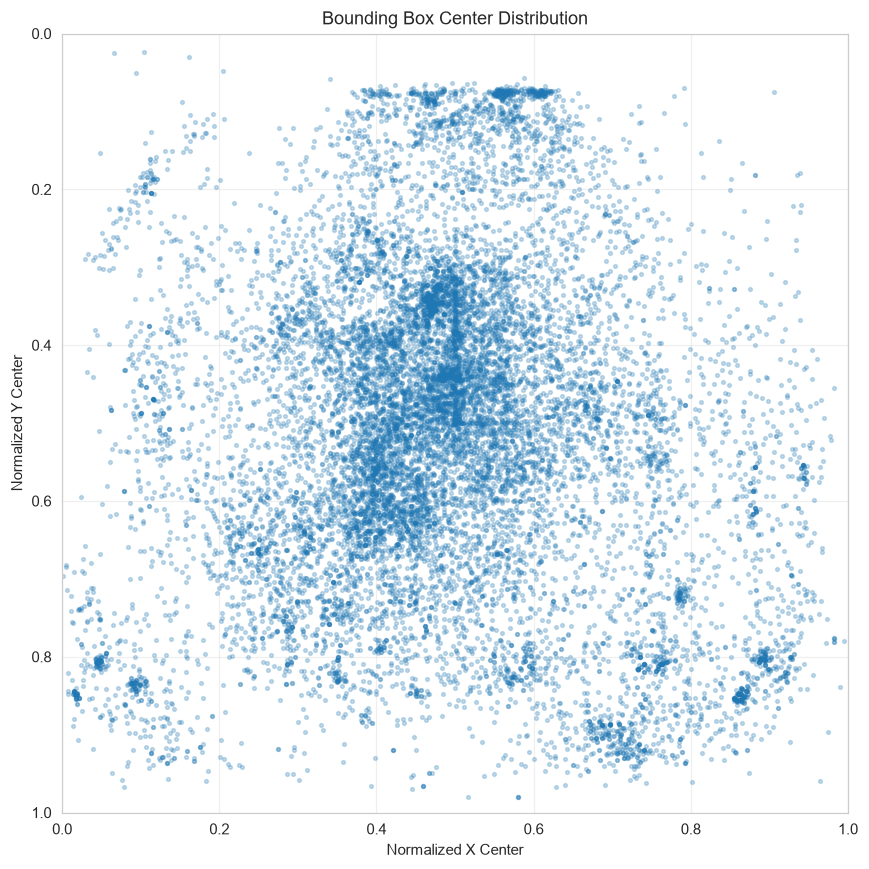

In [28]:
# ==========================================
# Step 8: Bounding Box Position Analysis
# ==========================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Local Windows Path
dataset_path = Path(r"C:\Users\User1\Downloads\fire_detection_project\fire.v2i.yolov8")

positions = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    if not label_folder.exists():
        continue

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r", encoding="utf-8") as file:

            for line in file:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                positions.append({
                    "Class ID": int(values[0]),
                    "X Center": float(values[1]),
                    "Y Center": float(values[2])
                })

# Create DataFrame
position_df = pd.DataFrame(positions)

print("=" * 60)
print("Bounding Box Center Summary")
print("=" * 60)

if not position_df.empty:
    display(position_df.describe())

    # Scatter Plot
    plt.figure(figsize=(8, 8))

    plt.scatter(
        position_df["X Center"],
        position_df["Y Center"],
        s=6,
        alpha=0.25
    )

    plt.title("Bounding Box Center Distribution")
    plt.xlabel("Normalized X Center")
    plt.ylabel("Normalized Y Center")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    # Match image coordinate system (origin at top-left)
    plt.gca().invert_yaxis()

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("❌ No position data found! Please check the dataset path.")

,Split,Class,Objects,Percentage
0,train,fire,10957,81.77
1,train,smoke,2442,18.23
2,valid,fire,1068,81.40
3,valid,smoke,244,18.60
4,test,fire,540,82.19
5,test,smoke,117,17.81


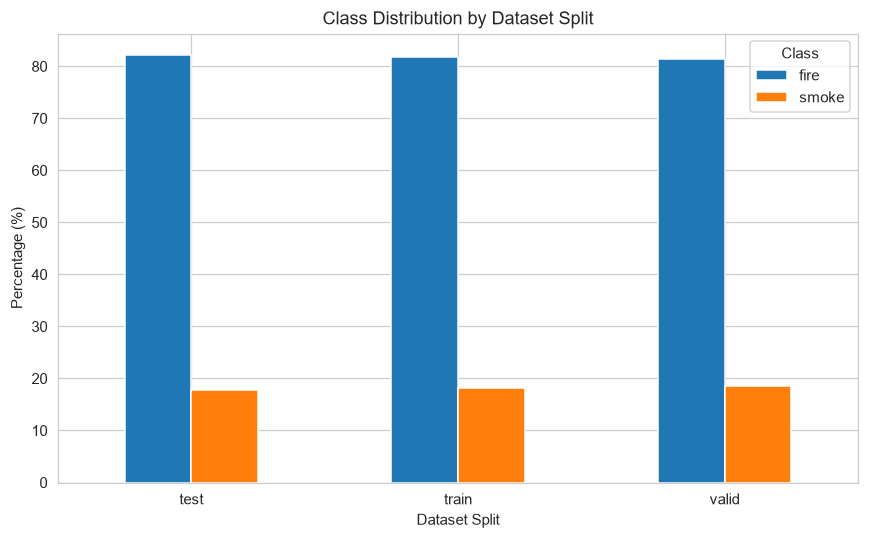

In [29]:
# ==========================================
# Step 9: Compare Dataset Splits
# ==========================================

from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# Local Windows path
dataset_path = Path(".")

# Read class names
class_names = dataset_config["names"]

results = []

for split in ["train", "valid", "test"]:

    counter = Counter()

    label_folder = dataset_path / split / "labels"

    if label_folder.exists():
        for label_file in label_folder.glob("*.txt"):

            with open(label_file, "r", encoding="utf-8") as file:

                for line in file:

                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    class_id = int(values[0])
                    c_name = class_names[class_id] if isinstance(class_names, dict) else class_names[class_id]

                    counter[c_name] += 1

    total = sum(counter.values())

    cls_iterable = class_names.values() if isinstance(class_names, dict) else class_names

    for cls in cls_iterable:

        count = counter[cls]

        percentage = count / total * 100 if total else 0

        results.append({
            "Split": split,
            "Class": cls,
            "Objects": count,
            "Percentage": round(percentage, 2)
        })

split_df = pd.DataFrame(results)

display(split_df)

# Plot
if not split_df.empty and split_df["Objects"].sum() > 0:
    pivot = split_df.pivot(
        index="Split",
        columns="Class",
        values="Percentage"
    )

    pivot.plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Class Distribution by Dataset Split")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Dataset Split")
    plt.xticks(rotation=0)
    plt.legend(title="Class")

    plt.tight_layout()
    plt.show()
else:
    print("❌ No objects found! Please check the dataset path.")

In [30]:
# ==========================================
# Step 10: Random Visual Inspection
# ==========================================

import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Main dataset folder (Local Windows Path)
dataset_path = Path(".")

# Read class names
class_names = dataset_config["names"]

image_folder = dataset_path / "train" / "images"
label_folder = dataset_path / "train" / "labels"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not image_folder.exists():
    print(f"❌ Directory not found: {image_folder}")
else:
    image_files = [
        file for file in image_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    if not image_files:
        print(f"❌ No images found in: {image_folder}")
    else:
        # Select up to 9 random images safely
        num_samples = min(9, len(image_files))
        random.seed(42)
        selected_images = random.sample(image_files, num_samples)

        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        axes = axes.flatten()

        for i, ax in enumerate(axes):
            if i < len(selected_images):
                image_path = selected_images[i]
                image = Image.open(image_path).convert("RGB")
                width, height = image.size

                ax.imshow(image)

                label_path = label_folder / f"{image_path.stem}.txt"

                if label_path.exists():
                    with open(label_path, "r", encoding="utf-8") as file:
                        for line in file:
                            values = line.strip().split()

                            if len(values) != 5:
                                continue

                            class_id = int(values[0])

                            x = float(values[1])
                            y = float(values[2])
                            w = float(values[3])
                            h = float(values[4])

                            w_pixel = w * width
                            h_pixel = h * height

                            x_pixel = x * width - w_pixel / 2
                            y_pixel = y * height - h_pixel / 2

                            rect = patches.Rectangle(
                                (x_pixel, y_pixel),
                                w_pixel,
                                h_pixel,
                                linewidth=2,
                                edgecolor="red",
                                facecolor="none"
                            )

                            ax.add_patch(rect)

                            c_name = class_names[class_id] if isinstance(class_names, dict) else class_names[class_id]

                            ax.text(
                                x_pixel,
                                max(0, y_pixel - 5),
                                str(c_name),
                                fontsize=8,
                                color="white",
                                bbox=dict(facecolor="red", alpha=0.7)
                            )

                ax.set_title(image_path.name, fontsize=8)
            ax.axis("off")

        plt.tight_layout()
        plt.show()

In [31]:
# ==========================================
# Step 11: Data Quality Assessment
# ==========================================

import pandas as pd

quality_summary = pd.DataFrame({

    "Criterion": [

        "Dataset Structure",
        "Image-Label Matching",
        "Corrupted Images",
        "Image Resolution",
        "Image Format",
        "Color Mode",
        "Class Distribution",
        "Objects per Image",
        "Bounding Box Size",
        "Bounding Box Position"

    ],

    "Finding": [

        "Well organized folder structure",
        "All images have matching label files",
        "No corrupted images detected",
        "640 × 640 pixels",
        "JPEG",
        "RGB",
        "Moderately imbalanced (Fire > Smoke)",
        "Average ≈ 1.82 objects per image",
        "Mostly small to medium objects",
        "Centered with good spatial diversity"

    ],

    "Assessment": [

        "Excellent",
        "Excellent",
        "Excellent",
        "Excellent",
        "Excellent",
        "Excellent",
        "Needs Attention",
        "Good",
        "Good",
        "Good"

    ],

    "Impact on Training": [

        "Easy dataset management",

        "Reliable annotations",

        "No preprocessing required",

        "Consistent model input",

        "Compatible with YOLO",

        "Standard color channels",

        "May introduce prediction bias",

        "Moderate scene complexity",

        "Small objects are harder to detect",

        "Good generalization capability"

    ]

})

quality_summary

,Criterion,Finding,Assessment,Impact on Training
0,Dataset Structure,Well organized folder structure,Excellent,Easy dataset management
1,Image-Label Matching,All images have matching label files,Excellent,Reliable annotations
2,Corrupted Images,No corrupted images detected,Excellent,No preprocessing required
3,Image Resolution,640 × 640 pixels,Excellent,Consistent model input
4,Image Format,JPEG,Excellent,Compatible with YOLO
5,Color Mode,RGB,Excellent,Standard color channels
6,Class Distribution,Moderately imbalanced (Fire > Smoke),Needs Attention,May introduce prediction bias
7,Objects per Image,Average ≈ 1.82 objects per image,Good,Moderate scene complexity
8,Bounding Box Size,Mostly small to medium objects,Good,Small objects are harder to detect
9,Bounding Box Position,Centered with good spatial diversity,Good,Good generalization capability


Class-wise Bounding Box Summary


Width                                                              \
         count      mean       std       min       25%       50%       75%   
Class                                                                        
fire   12565.0  0.234745  0.211240  0.002644  0.078182  0.164919  0.317788   
smoke   2803.0  0.572515  0.285248  0.009375  0.311880  0.580810  0.853125   

             Height            ...                    Area            \
       max    count      mean  ...       75%  max    count      mean   
Class                          ...                                     
fire   1.0  12565.0  0.298365  ...  0.446875  1.0  12565.0  0.108326   
smoke  1.0   2803.0  0.337455  ...  0.426563  1.0   2803.0  0.198110   

                                                              
            std       min       25%       50%       75%  max  
Class                                                         
fire   0.174128  0.000088  0.007582  0.034607  0.131335  1.0  
smoke  0.156718  0.000146  0.099058  0.158232  0.248266  1.0  

[2 rows x 24 columns]

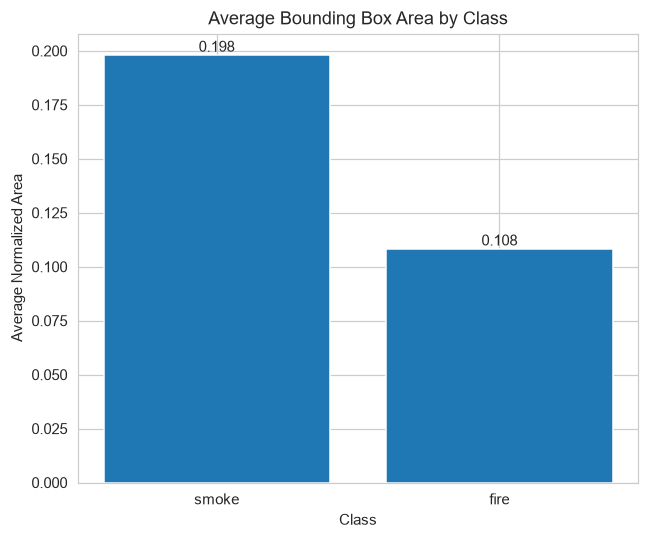

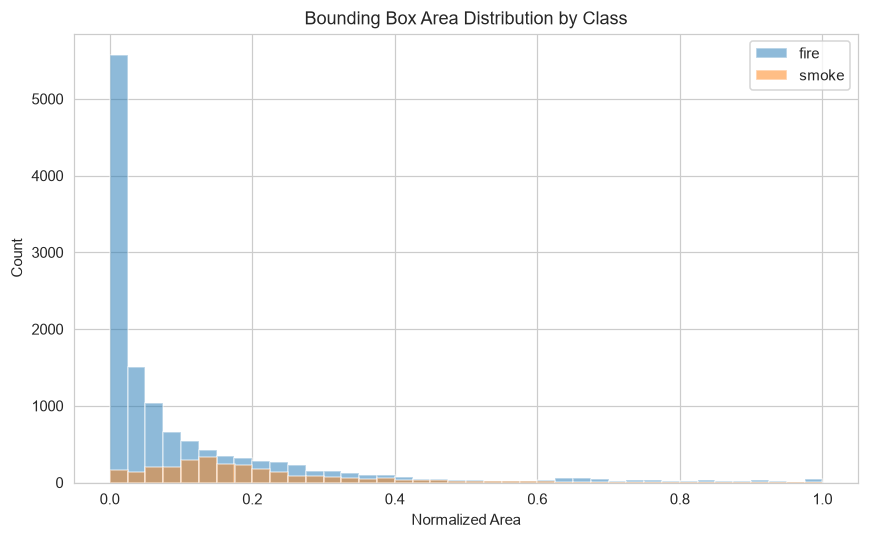

In [32]:
# ==========================================
# Step 12: Class-wise Bounding Box Analysis
# ==========================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Local Windows path
dataset_path = Path(".")

# Read class names
class_names = dataset_config["names"]

records = []

for split in ["train", "valid", "test"]:

    label_folder = dataset_path / split / "labels"

    if not label_folder.exists():
        continue

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r", encoding="utf-8") as file:

            for line in file:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id = int(values[0])

                width = float(values[3])
                height = float(values[4])

                area = width * height

                c_name = class_names[class_id] if isinstance(class_names, dict) else class_names[class_id]

                records.append({
                    "Class": c_name,
                    "Width": width,
                    "Height": height,
                    "Area": area
                })

bbox_class_df = pd.DataFrame(records)

print("=" * 60)
print("Class-wise Bounding Box Summary")
print("=" * 60)

if not bbox_class_df.empty:
    # Summary
    summary = (
        bbox_class_df
        .groupby("Class")[["Width", "Height", "Area"]]
        .describe()
    )

    display(summary)

    # Mean Area per Class
    mean_area = (
        bbox_class_df
        .groupby("Class")["Area"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(6, 5))

    bars = plt.bar(
        mean_area.index,
        mean_area.values
    )

    plt.title("Average Bounding Box Area by Class")
    plt.xlabel("Class")
    plt.ylabel("Average Normalized Area")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    # Area Distribution
    plt.figure(figsize=(8, 5))

    for cls in bbox_class_df["Class"].unique():

        plt.hist(
            bbox_class_df.loc[
                bbox_class_df["Class"] == cls,
                "Area"
            ],
            bins=40,
            alpha=0.5,
            label=cls
        )

    plt.title("Bounding Box Area Distribution by Class")
    plt.xlabel("Normalized Area")
    plt.ylabel("Count")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("❌ No bounding box data found! Please check the dataset path.")

## Part 4 — Data Preprocessing

This pipeline cleans the dataset and converts it into the YOLO training format:

1. **Remove corrupted images** — unreadable files are dropped from the working set.
2. **Validate bounding boxes** — boxes with non-positive width/height or coordinates
   outside the image bounds are flagged.
3. **Remove invalid annotations** — invalid rows are dropped before conversion.
4. **Remove duplicate annotations** — exact duplicate rows are dropped.
5. **Convert CSV → YOLO format** — `(class x_center y_center width height)`, all
   normalized to `[0, 1]`.
6. **Generate `dataset.yaml`** — the config file Ultralytics YOLO reads for training.
7. **Verify labels** — cross-check that every image has a corresponding label file.
8. **Resize / normalize** — YOLOv8 handles resizing and normalization internally at
   train time, but we still verify image readability at the target size (640×640).


In [33]:
# ==========================================
# Step 8: Dataset Cleaning & Preprocessing
# ==========================================

from pathlib import Path
import pandas as pd
from PIL import Image

# Use current working directory
dataset_path = Path(".")

# 1. Function to check for corrupted images
def check_corrupted_images(images_dir: Path) -> list:
    corrupted = []
    if not images_dir.exists():
        return corrupted
        
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    for img_path in images_dir.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                corrupted.append(img_path.name)
    return corrupted

# 2. Function to validate bounding box dimensions
def validate_boxes(df: pd.DataFrame) -> pd.DataFrame:
    """Return only rows with geometrically valid bounding boxes."""
    if df.empty:
        return df
        
    # Check bounding box limits
    valid = (
        (df["xmax"] > df["xmin"]) &
        (df["ymax"] > df["ymin"]) &
        (df["xmin"] >= 0) & (df["ymin"] >= 0) &
        (df["xmax"] <= df["width"]) & (df["ymax"] <= df["height"])
    )
    n_invalid = (~valid).sum()
    if n_invalid > 0:
        print(f"[CLEANING] Dropping {n_invalid} geometrically invalid boxes.")
    return df[valid].reset_index(drop=True)

# 3. Function to remove duplicate annotations
def remove_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    before = len(df)
    df = df.drop_duplicates(subset=["filename", "class", "xmin", "ymin", "xmax", "ymax"]).reset_index(drop=True)
    removed = before - len(df)
    if removed > 0:
        print(f"[CLEANING] Removed {removed} duplicate annotation rows.")
    return df

# 4. Function to filter out corrupted images
def filter_corrupted(df: pd.DataFrame, images_dir: Path) -> pd.DataFrame:
    if df.empty:
        return df
    corrupted = set(check_corrupted_images(images_dir))
    if corrupted:
        print(f"[CLEANING] Removing {len(corrupted)} corrupted images from annotations.")
        df = df[~df["filename"].isin(corrupted)].reset_index(drop=True)
    return df

# 5. Master cleaning function for a split
def clean_split(df: pd.DataFrame, images_dir: Path) -> pd.DataFrame:
    df = filter_corrupted(df, images_dir)
    df = validate_boxes(df)
    df = remove_duplicate_rows(df)
    return df

# Helper to build initial DataFrame for a split from YOLO txt annotations
def load_split_dataframe(split_name: str) -> pd.DataFrame:
    records = []
    split_dir = dataset_path / split_name
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"
    
    if not img_dir.exists() or not lbl_dir.exists():
        return pd.DataFrame()

    for lbl_file in lbl_dir.glob("*.txt"):
        img_name = lbl_file.stem + ".jpg" # Default extension
        
        # Try finding actual image extension
        for ext in [".jpg", ".png", ".jpeg", ".webp"]:
            if (img_dir / f"{lbl_file.stem}{ext}").exists():
                img_path = img_dir / f"{lbl_file.stem}{ext}"
                img_name = img_path.name
                break
        else:
            img_path = img_dir / img_name

        width, height = 640, 640  # Default fallback values
        if img_path.exists():
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
            except Exception:
                pass

        with open(lbl_file, "r", encoding="utf-8") as f:
            for line in f:
                vals = line.strip().split()
                if len(vals) == 5:
                    cls_id, xc, yc, w, h = map(float, vals)
                    
                    # Convert YOLO format (normalized center) to absolute Pascal VOC (xmin, ymin, xmax, ymax)
                    abs_w = w * width
                    abs_h = h * height
                    abs_xc = xc * width
                    abs_yc = yc * height
                    
                    xmin = abs_xc - (abs_w / 2)
                    ymin = abs_yc - (abs_h / 2)
                    xmax = abs_xc + (abs_w / 2)
                    ymax = abs_yc + (abs_h / 2)

                    records.append({
                        "filename": img_name,
                        "class": int(cls_id),
                        "xmin": xmin,
                        "ymin": ymin,
                        "xmax": xmax,
                        "ymax": ymax,
                        "width": width,
                        "height": height
                    })
    return pd.DataFrame(records)

# Executing Data Loading & Cleaning
print("Loading split DataFrames...")
train_df = load_split_dataframe("train")
valid_df = load_split_dataframe("valid")
test_df = load_split_dataframe("test")

print("\nCleaning TRAIN split...")
train_df_clean = clean_split(train_df, dataset_path / "train" / "images")

print("Cleaning VALID split...")
valid_df_clean = clean_split(valid_df, dataset_path / "valid" / "images")

print("Cleaning TEST split...")
test_df_clean = clean_split(test_df, dataset_path / "test" / "images")

print("\n✅ Preprocessing (cleaning) complete.")

Loading split DataFrames...

Cleaning TRAIN split...
[CLEANING] Removed 190 duplicate annotation rows.
Cleaning VALID split...
[CLEANING] Removed 23 duplicate annotation rows.
Cleaning TEST split...
[CLEANING] Removed 14 duplicate annotation rows.

✅ Preprocessing (cleaning) complete.


In [35]:
from pathlib import Path
import yaml
import pandas as pd

# Use current working directory
dataset_path = Path(".")
yaml_path = dataset_path / "data.yaml"

# 1. Read classes from data.yaml
class_names = []
if yaml_path.exists():
    with open(yaml_path, "r", encoding="utf-8") as f:
        data_config = yaml.safe_load(f)
        names = data_config.get("names", [])
        if isinstance(names, dict):
            class_names = list(names.values())
        else:
            class_names = names

print(f"Detected classes: {class_names}")

if not class_names:
    print("❌ No classes found! Please check data.yaml.")
else:
    print(f"✅ Successfully found {len(class_names)} classes.")


# 2. Function to parse YOLO annotations safely
def load_annotations_from_labels(split_name: str) -> pd.DataFrame:
    records = []
    split_dir = dataset_path / split_name
    lbl_dir = split_dir / "labels"

    if not lbl_dir.exists():
        print(f"[WARNING] Labels directory not found for split: {split_name}")
        return pd.DataFrame()

    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file, "r", encoding="utf-8") as f:
            for line in f:
                vals = line.strip().split()
                if len(vals) == 5:
                    cls_id = int(vals[0])
                    # Map class ID to class name safely
                    if isinstance(class_names, list) and cls_id < len(class_names):
                        c_name = class_names[cls_id]
                    else:
                        c_name = str(cls_id)

                    records.append({
                        "filename": f"{lbl_file.stem}.jpg",
                        "class_id": cls_id,
                        "class": c_name,
                        "x_center": float(vals[1]),
                        "y_center": float(vals[2]),
                        "width": float(vals[3]),
                        "height": float(vals[4])
                    })

    return pd.DataFrame(records)


# 3. Read train, valid, test splits
print("\n[INFO] Reading train annotations from local path...")
train_df = load_annotations_from_labels("train")

print("[INFO] Reading valid annotations from local path...")
valid_df = load_annotations_from_labels("valid")

print("[INFO] Reading test annotations from local path...")
test_df = load_annotations_from_labels("test")

# Combine all annotations
all_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

if not all_df.empty:
    print(f"\n✅ Total annotations loaded: {len(all_df)}")
    display(all_df.head())
else:
    print("\n❌ No annotation records were created. Please verify your label files.")

Detected classes: ['fire', 'smoke']
✅ Successfully found 2 classes.

[INFO] Reading train annotations from local path...
[INFO] Reading valid annotations from local path...
[INFO] Reading test annotations from local path...

✅ Total annotations loaded: 15368


,filename,class_id,class,x_center,y_center,width,height
0,0050_jpg.rf.4e03b70ab97e60c7fede569be2942ed9.jpg,0,fire,0.535156,0.693750,0.264062,0.181250
1,0050_jpg.rf.d26a43c1bae75de2882b94da4e9b3510.jpg,0,fire,0.537137,0.689204,0.276847,0.198494
2,0050_jpg.rf.e8b54db77ff3417734d86ad07bdbc481.jpg,0,fire,0.568533,0.665081,0.282382,0.212881
3,0055_jpg.rf.2286b2e289e83f768f1db192a669c573.jpg,1,smoke,0.474789,0.194515,0.113011,0.318232
4,0055_jpg.rf.2286b2e289e83f768f1db192a669c573.jpg,0,fire,0.402777,0.277147,0.179273,0.376359


In [36]:
# ==========================================
# Step 14: Label Verification
# ==========================================

import os
from pathlib import Path

# Use current working directory as YOLO Dataset path
YOLO_DATA_DIR = "."

def verify_images_labels_match(split_name: str, out_root: str):
    img_dir = os.path.join(out_root, split_name, "images")
    lbl_dir = os.path.join(out_root, split_name, "labels")

    if not os.path.isdir(img_dir) or not os.path.isdir(lbl_dir):
        print(f"[SKIPPED] {split_name}: converted folders not found at {os.path.abspath(os.path.join(out_root, split_name))}")
        return

    # Extract filenames without extensions
    images = {os.path.splitext(f)[0] for f in os.listdir(img_dir) if not f.startswith('.')}
    labels = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if not f.startswith('.')}

    missing_labels = images - labels
    orphan_labels = labels - images

    print(f"[{split_name.upper()}] images={len(images)} labels={len(labels)} "
          f"missing_labels={len(missing_labels)} orphan_labels={len(orphan_labels)}")

    for f in list(missing_labels)[:5]:
        print(f"  - missing label for image: {f}")
    for f in list(orphan_labels)[:5]:
        print(f"  - orphan label with no image: {f}")

# Run verification for all splits
for split in ["train", "valid", "test"]:
    verify_images_labels_match(split, YOLO_DATA_DIR)

[TRAIN] images=7407 labels=7407 missing_labels=0 orphan_labels=0
[VALID] images=702 labels=702 missing_labels=0 orphan_labels=0
[TEST] images=347 labels=347 missing_labels=0 orphan_labels=0


In [37]:
# ==========================================
# Step 15: Resize / Normalization Check
# ==========================================

import os
import random
import cv2
import numpy as np

# Use current working directory as YOLO Dataset path
YOLO_DATA_DIR = "."
TARGET_IMG_SIZE = 640

def check_resize_readiness(out_root: str, split_name: str, target_size: int = 640, sample_n: int = 50):
    img_dir = os.path.join(out_root, split_name, "images")
    
    if not os.path.isdir(img_dir):
        print(f"[SKIPPED] {split_name}: no images directory found at {os.path.abspath(img_dir)}.")
        return

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    files = [f for f in os.listdir(img_dir) if os.path.splitext(f)[1].lower() in image_extensions]

    if not files:
        print(f"[SKIPPED] {split_name}: no valid images found in {img_dir}.")
        return

    sample = random.sample(files, min(sample_n, len(files)))
    ok, fail = 0, 0

    for fname in sample:
        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path)
        
        if img is None:
            fail += 1
            continue

        resized = cv2.resize(img, (target_size, target_size))
        normalized = resized.astype(np.float32) / 255.0

        if normalized.shape == (target_size, target_size, 3):
            ok += 1
        else:
            fail += 1

    print(f"[{split_name.upper()}] resize/normalize check: {ok} OK, {fail} failed (sampled {len(sample)} images).")

# Run check for all splits
for split in ["train", "valid", "test"]:
    check_resize_readiness(YOLO_DATA_DIR, split, TARGET_IMG_SIZE)

[TRAIN] resize/normalize check: 50 OK, 0 failed (sampled 50 images).
[VALID] resize/normalize check: 50 OK, 0 failed (sampled 50 images).
[TEST] resize/normalize check: 50 OK, 0 failed (sampled 50 images).


## Part 5 — Data Augmentation

YOLOv8's built-in training loop already applies Mosaic, MixUp, HSV shift, flips,
rotation, translation, and scaling automatically through its augmentation pipeline
(configured via training hyperparameters in Part 7). To make these transformations
**visible and explainable**, this section also implements each augmentation manually
with OpenCV/Albumentations-style code and renders a before/after comparison on a real
sample image.

**Why each augmentation helps fire detection:**
- **Horizontal Flip** — fire has no canonical left/right orientation; doubles effective
  training variety at no annotation cost.
- **Vertical Flip** — used sparingly; fire/smoke plumes rise, so vertical flips are
  only mildly useful and can even hurt realism — kept optional and low-probability.
- **Rotation** — cameras are rarely perfectly level (CCTV, drones); improves robustness
  to tilt.
- **Translation** — fire is not always centered; teaches the model to detect at any
  position in the frame.
- **Scaling** — fires vary hugely in size (spark vs. building fire); simulates
  near/far camera distances.
- **HSV Augmentation** — fire color varies with fuel, lighting, and camera white
  balance; hue/saturation/value jitter improves color robustness.
- **Mosaic** — combines 4 images into one, exposing the model to more object scales
  and contexts per batch — especially valuable for small/rare fire instances.
- **MixUp** — blends two images/labels, smoothing decision boundaries and reducing
  overfitting on a typically small fire dataset.
- **Random Brightness / Contrast** — fires are often the brightest area of night
  scenes, and also occur in daylight — simulate both extremes.


In [38]:
!pip install albumentations

[notice] A new release of pip available: 22.3 -> 26.2.1


In [39]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Use relative current working directory
dataset_path = Path(".")
train_images_dir = dataset_path / "train" / "images"
train_labels_dir = dataset_path / "train" / "labels"

def load_sample_image_and_boxes():
    if not train_images_dir.exists() or not train_labels_dir.exists():
        return None, None

    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    image_files = [
        f for f in train_images_dir.iterdir()
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]

    if not image_files:
        return None, None

    # Pick a sample image that has a matching non-empty label file
    sample_img_path = None
    sample_label_path = None

    for img_file in image_files:
        lbl_file = train_labels_dir / f"{img_file.stem}.txt"
        if lbl_file.exists() and lbl_file.stat().st_size > 0:
            sample_img_path = img_file
            sample_label_path = lbl_file
            break

    if sample_img_path is None:
        return None, None

    # Read Image
    img = cv2.imread(str(sample_img_path))
    if img is None:
        return None, None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Read YOLO Labels and convert to absolute coordinates [xmin, ymin, xmax, ymax]
    boxes = []
    with open(sample_label_path, "r", encoding="utf-8") as f:
        for line in f:
            vals = line.strip().split()
            if len(vals) == 5:
                _, cx, cy, bw, bh = map(float, vals)
                xmin = (cx - bw / 2) * w
                ymin = (cy - bh / 2) * h
                xmax = (cx + bw / 2) * w
                ymax = (cy + bh / 2) * h
                boxes.append([xmin, ymin, xmax, ymax])

    return img, boxes


# --- Augmentation Functions ---

def hflip(img, boxes):
    w = img.shape[1]
    flipped = cv2.flip(img, 1)
    new_boxes = [[w - xmax, ymin, w - xmin, ymax] for xmin, ymin, xmax, ymax in boxes]
    return flipped, new_boxes

def vflip(img, boxes):
    h = img.shape[0]
    flipped = cv2.flip(img, 0)
    new_boxes = [[xmin, h - ymax, xmax, h - ymin] for xmin, ymin, xmax, ymax in boxes]
    return flipped, new_boxes

def rotate(img, boxes, angle=15):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated, boxes

def translate(img, boxes, tx=30, ty=20):
    h, w = img.shape[:2]
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    translated = cv2.warpAffine(img, M, (w, h))
    new_boxes = [[xmin + tx, ymin + ty, xmax + tx, ymax + ty] for xmin, ymin, xmax, ymax in boxes]
    return translated, new_boxes

def scale(img, boxes, factor=1.2):
    h, w = img.shape[:2]
    scaled = cv2.resize(img, None, fx=factor, fy=factor)
    new_boxes = [[xmin * factor, ymin * factor, xmax * factor, ymax * factor] for xmin, ymin, xmax, ymax in boxes]
    return scaled, new_boxes

def hsv_augment(img, boxes, h_gain=0.02, s_gain=0.4, v_gain=0.3):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 0] = (hsv[..., 0] * (1 + random.uniform(-h_gain, h_gain))) % 180
    hsv[..., 1] = np.clip(hsv[..., 1] * (1 + random.uniform(-s_gain, s_gain)), 0, 255)
    hsv[..., 2] = np.clip(hsv[..., 2] * (1 + random.uniform(-v_gain, v_gain)), 0, 255)
    out = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    return out, boxes

def random_brightness(img, boxes, factor_range=(0.6, 1.4)):
    factor = random.uniform(*factor_range)
    out = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    return out, boxes

def random_contrast(img, boxes, factor_range=(0.6, 1.4)):
    factor = random.uniform(*factor_range)
    mean = img.mean()
    out = np.clip((img.astype(np.float32) - mean) * factor + mean, 0, 255).astype(np.uint8)
    return out, boxes

def mosaic_augment(images: list, size=640):
    if len(images) < 4:
        images = (images * 4)[:4]
    half = size // 2
    mosaic = np.zeros((size, size, 3), dtype=np.uint8)
    positions = [(0, 0), (0, half), (half, 0), (half, half)]
    for img, (y, x) in zip(images, positions):
        tile = cv2.resize(img, (half, half))
        mosaic[y:y + half, x:x + half] = tile
    return mosaic

def mixup_augment(img1, img2, alpha=0.5):
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    mixed = cv2.addWeighted(img1, alpha, img2, 1 - alpha, 0)
    return mixed


# --- Execution ---

sample_img, sample_boxes = load_sample_image_and_boxes()

if sample_img is not None:
    augmentations = {
        "Original": (sample_img, sample_boxes),
        "H-Flip": hflip(sample_img, sample_boxes),
        "V-Flip": vflip(sample_img, sample_boxes),
        "Rotate": rotate(sample_img, sample_boxes),
        "Translate": translate(sample_img, sample_boxes),
        "Scale": scale(sample_img, sample_boxes),
        "HSV": hsv_augment(sample_img, sample_boxes),
        "Brightness": random_brightness(sample_img, sample_boxes),
        "Contrast": random_contrast(sample_img, sample_boxes),
    }

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    for ax, (name, (aug_img, aug_boxes)) in zip(axes.flatten(), augmentations.items()):
        vis = aug_img.copy()
        for xmin, ymin, xmax, ymax in aug_boxes:
            cv2.rectangle(vis, (int(xmin), int(ymin)), (int(xmax), int(ymax)), (255, 0, 0), 3)
        ax.imshow(vis)
        ax.set_title(name)
        ax.axis("off")
    fig.suptitle("Augmentation Before/After Comparison", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- Mosaic / MixUp Demo ---
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    img_files = [
        f for f in train_images_dir.iterdir()
        if f.is_file() and f.suffix.lower() in valid_extensions
    ]

    pool_imgs = []
    for img_p in img_files[:4]:
        img = cv2.imread(str(img_p))
        if img is not None:
            pool_imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    if len(pool_imgs) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        mosaic_img = mosaic_augment(pool_imgs)
        axes[0].imshow(mosaic_img)
        axes[0].set_title("Mosaic Augmentation (4-image tile)")
        axes[0].axis("off")

        mixup_img = mixup_augment(pool_imgs[0], pool_imgs[1])
        axes[1].imshow(mixup_img)
        axes[1].set_title("MixUp Augmentation")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("[SKIPPED] Augmentation demo - no sample image available yet.")

## Part 6 — Model Building

We build and later compare three YOLOv8 variants of increasing capacity:

| Model | Parameters | Why selected |
|---|---|---|
| **YOLOv8n** | ~3.2M | Nano — fastest, ideal for edge/embedded fire alarms with real-time constraints |
| **YOLOv8s** | ~11.2M | Small — a strong accuracy/speed trade-off for typical CCTV/server deployment |
| **YOLOv8m** | ~25.9M | Medium — higher capacity for maximum accuracy when compute allows |

All models start from **COCO-pretrained weights** (transfer learning), which is
especially valuable for fire detection since fire datasets are usually small — the
pretrained backbone already understands general edges/textures/shapes.


In [40]:
YOLO_VARIANTS = {
    "yolov8n": "yolov8n.pt",
    "yolov8s": "yolov8s.pt",
    "yolov8m": "yolov8m.pt",
}

def load_yolo_model(weights_name: str):
    """Load a YOLOv8 model, downloading pretrained COCO weights automatically if possible."""
    if not ULTRALYTICS_AVAILABLE:
        print("[ERROR] 'ultralytics' is not installed. Run: pip install ultralytics")
        return None
    try:
        model = YOLO(weights_name)
        print(f"[OK] Loaded {weights_name} (pretrained weights auto-downloaded if not cached locally).")
        return model
    except Exception as e:
        print(f"[ERROR] Could not load/download {weights_name}: {e}")
        print("        If you have no internet access, manually download the weights from:")
        print(f"        https://github.com/ultralytics/assets/releases/download/v8.2.0/{weights_name}")
        print(f"        and place the file in: {os.getcwd()}")
        return None


models = {}
if ULTRALYTICS_AVAILABLE:
    for name, weights in YOLO_VARIANTS.items():
        print(f"Loading {name}...")
        models[name] = load_yolo_model(weights)
else:
    print("[SKIPPED] Model loading — ultralytics package not available in this environment.")


Loading yolov8n...
[OK] Loaded yolov8n.pt (pretrained weights auto-downloaded if not cached locally).
Loading yolov8s...
[OK] Loaded yolov8s.pt (pretrained weights auto-downloaded if not cached locally).
Loading yolov8m...
[OK] Loaded yolov8m.pt (pretrained weights auto-downloaded if not cached locally).


## Part 7 — Model Training

Each variant is trained with identical hyperparameters for a fair comparison:

- Image size: **640**
- Epochs: **50**
- Batch size: **16**
- Early stopping (`patience`)
- Automatic mixed precision (`amp=True`, enabled by default on CUDA)
- Automatic device selection (GPU if available, else CPU)
- Checkpoints and logs saved automatically by Ultralytics under `runs/`


In [41]:
# ------------------------------------------------------------------
# Package check (installed only if missing — does not touch existing installs)
# ------------------------------------------------------------------
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])

_ensure("torchvision")
_ensure("torchmetrics")
_ensure("pycocotools")

import os, time, copy, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as TF
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------------
# GPU / precision setup (shared by every extended model below)
# ------------------------------------------------------------------
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
USE_AMP = TORCH_DEVICE.type == "cuda"

print(f"[Extended Benchmark] Torch device : {TORCH_DEVICE}")
print(f"[Extended Benchmark] AMP enabled  : {USE_AMP}")
print(f"[Extended Benchmark] cudnn.benchmark = {torch.backends.cudnn.benchmark}")

# Shared results store — one row per model, filled in by each section below.
if "all_models_results" not in globals():
    all_models_results = {}

EXT_MODELS_DIR = os.path.join(MODELS_DIR, "extended")
EXT_RUNS_DIR   = os.path.join(RUNS_DIR, "extended")
os.makedirs(EXT_MODELS_DIR, exist_ok=True)
os.makedirs(EXT_RUNS_DIR, exist_ok=True)

NUM_FG_CLASSES = len(CLASS_LIST) if "CLASS_LIST" in globals() and CLASS_LIST else 1
print(f"[Extended Benchmark] Foreground classes: {NUM_FG_CLASSES} -> {CLASS_LIST if 'CLASS_LIST' in globals() else 'N/A'}")

[Extended Benchmark] Torch device : cuda
[Extended Benchmark] AMP enabled  : True
[Extended Benchmark] cudnn.benchmark = True
[Extended Benchmark] Foreground classes: 1 -> N/A


In [42]:
import os
import yaml
import time
from pathlib import Path

# ==========================================
# ==========================================
CLASS_NAMES = ["fire", "smoke"]  

base_dataset_dir = os.path.abspath(".").replace("\\", "/")
DATASET_PATH = base_dataset_dir

names_dict = {i: name for i, name in enumerate(CLASS_NAMES)}

# ==========================================
# ==========================================
yaml_data = {
    'path': base_dataset_dir,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images' if os.path.exists(os.path.join(base_dataset_dir, 'test')) else 'valid/images',
    'nc': len(CLASS_NAMES),
    'names': names_dict       # {0: 'fire', 1: 'smoke'}
}

corrected_yaml_path = os.path.join(base_dataset_dir, "data_fixed.yaml").replace("\\", "/")
with open(corrected_yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"✅ Created YAML config with {len(CLASS_NAMES)} classes: {names_dict}")
print(f"📄 Config saved at: {corrected_yaml_path}")

# ==========================================
# ==========================================
DEVICE = globals().get('DEVICE', 'cpu')
SEED = globals().get('SEED', 42)
RUNS_DIR = globals().get('RUNS_DIR', 'runs')
ULTRALYTICS_AVAILABLE = globals().get('ULTRALYTICS_AVAILABLE', True)

TRAIN_CONFIG = dict(
    imgsz=640,
    epochs=50,
    batch=16,
    patience=15,       # early stopping
    device=DEVICE,
    seed=SEED,
    amp=False,         # set False for CPU stability
    workers=0,         # set 0 for Windows stability
    project=RUNS_DIR,
    verbose=True,
)

training_results = {}

def train_model(name: str, model, data_yaml: str):
    if model is None:
        print(f"[SKIPPED] {name}: model not loaded.")
        return None
    if not os.path.isfile(data_yaml):
        print(f"[SKIPPED] {name}: dataset.yaml not found at {data_yaml}.")
        return None
    
    print(f"\n{'=' * 70}\nTraining {name} with classes: {CLASS_NAMES}\n{'=' * 70}")
    start = time.time()
    try:
        results = model.train(data=data_yaml, name=name, **TRAIN_CONFIG)
        elapsed = time.time() - start
        print(f"[DONE] {name} trained in {elapsed / 60:.1f} minutes.")
        return {"results": results, "train_time_sec": elapsed}
    except Exception as e:
        print(f"[ERROR] Training failed for {name}: {e}")
        return None

# ==========================================
# ==========================================
if ULTRALYTICS_AVAILABLE and os.path.isfile(corrected_yaml_path) and 'models' in globals():
    for name, model in models.items():
        training_results[name] = train_model(name, model, corrected_yaml_path)
else:
    print("[SKIPPED] Training — models dictionary or setup not ready yet.")

In [66]:
import glob, os, pandas as pd

candidates = sorted(glob.glob(os.path.join(RUNS_DIR, "yolov8n*")))
print("The existing folders:")
best_folder, max_epochs = None, -1

for c in candidates:
    csv_path = os.path.join(c, "results.csv")
    if os.path.isfile(csv_path):
        n_epochs = len(pd.read_csv(csv_path))
        print(f"  {c}  ->  {n_epochs} epoch")
        if n_epochs > max_epochs:
            max_epochs, best_folder = n_epochs, c
    else:
        print(f"  {c}  ->  There is no results.csv (meaning it stopped without saving the results)")



The existing folders:
  c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8n  ->  There is no results.csv (meaning it stopped without saving the results)
  c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8n-2  ->  There is no results.csv (meaning it stopped without saving the results)
  c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8n-3  ->  There is no results.csv (meaning it stopped without saving the results)
  c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8n-4  ->  50 epoch


In [67]:
from ultralytics import YOLO
import os

if "training_results" not in globals():
    training_results = {}
if "models" not in globals():
    models = {}

yolov8n_run_dir = os.path.join(RUNS_DIR, "yolov8n-4")
yolov8n_weights = os.path.join(yolov8n_run_dir, "weights", "best.pt")

if os.path.isfile(yolov8n_weights):
    models["yolov8n"] = YOLO(yolov8n_weights)
    training_results["yolov8n"] = {"results": None, "train_time_sec": None}
    print("[INFO] The full YOLOv8n weights (50 epochs) were loaded without retraining:")
    print("      ", yolov8n_weights)
else:
    print("[WARNING] The file does not exist:", yolov8n_weights)

[INFO] The full YOLOv8n weights (50 epochs) were loaded without retraining:
       c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8n-4\weights\best.pt


In [69]:
import glob, os, pandas as pd

candidates = sorted(glob.glob(os.path.join(RUNS_DIR, "yolov8s*")))
print("Available folders:")
best_folder, max_epochs = None, -1

for c in candidates:
    csv_path = os.path.join(c, "results.csv")
    if os.path.isfile(csv_path):
        n_epochs = len(pd.read_csv(csv_path))
        print(f"  {c}  ->  {n_epochs} epochs")
        if n_epochs > max_epochs:
            max_epochs, best_folder = n_epochs, c
    else:
        print(f"  {c}  ->  no results.csv found")

print(f"\n[INFO] Most complete folder: {best_folder} with {max_epochs} epochs")

Available folders:
  c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8s  ->  1 epochs

[INFO] Most complete folder: c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8s with 1 epochs


In [70]:
from ultralytics import YOLO

extra_variants = {
    "yolov8s": "yolov8s.pt",
    "yolov8m": "yolov8m.pt",
}

for name, weights_file in extra_variants.items():
    print(f"\n{'='*70}\nStarting training for {name}\n{'='*70}")
    model = YOLO(weights_file)
    models[name] = model
    training_results[name] = train_model(name, model, corrected_yaml_path)

## Part 8 — Model Evaluation

Metrics explained:

- **Precision** — of all predicted fire boxes, how many were correct (low precision =
  many false alarms).
- **Recall** — of all real fires, how many were detected (low recall = missed fires —
  the most dangerous failure mode for this application).
- **mAP@0.5** — mean Average Precision at IoU threshold 0.5 (standard detection metric).
- **mAP@0.5:0.95** — averaged over IoU thresholds 0.5→0.95, a stricter localization metric.
- **F1 Score** — harmonic mean of precision and recall, balancing false alarms vs. misses.
- **Confusion Matrix** — class-level breakdown of correct vs. incorrect predictions.
- **PR Curve** — precision/recall trade-off across confidence thresholds.
- **Loss Curves** — training/validation loss over epochs, to check convergence and overfitting.
- **Inference Speed / FPS** — how fast the model runs, critical for real-time alarm systems.


In [80]:
eval_yaml_path = corrected_yaml_path if "corrected_yaml_path" in globals() and os.path.isfile(corrected_yaml_path) else DATASET_YAML_PATH
print("Using yaml file for evaluation:", eval_yaml_path)
print("File exists:", os.path.isfile(eval_yaml_path))

Using yaml file for evaluation: c:/Users/User1/Desktop/fire.v2i.yolov8 (2)/fire.v2i.yolov8/data_fixed.yaml
File exists: True


In [81]:
def evaluate_model(name: str, model, data_yaml: str):
    if model is None or not os.path.isfile(data_yaml):
        print(f"[SKIPPED] {name}: not ready for evaluation.")
        return None
    try:
        metrics = model.val(data=data_yaml, imgsz=640, device=DEVICE, split="test")
        return metrics
    except Exception as e:
        print(f"[ERROR] Evaluation failed for {name}: {e}")
        return None


evaluation_results = {}
if DATASET_READY and ULTRALYTICS_AVAILABLE and training_results:
    for name, model in models.items():
        if training_results.get(name) is not None:
            print(f"Evaluating {name}...")
            evaluation_results[name] = evaluate_model(name, model, eval_yaml_path)
else:
    print("[SKIPPED] Evaluation — no trained models available yet.")

Evaluating yolov8n...
Ultralytics 8.4.114  Python-3.11.0 torch-2.4.1+cu121 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 16380MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 222.3101.8 MB/s, size: 43.4 KB)
val: Scanning C:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\test\labels... 347 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 347/347 1.4Kit/s 0.3s<0.1s
val: C:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\test\images\Img_1330_jpg.rf.0a5b5be47992c0491aa1b423698b211e.jpg: 3 duplicate labels removed
val: C:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\test\images\Img_1355_jpg.rf.f64a25e809118eb48c23b276707e3710.jpg: 4 duplicate labels removed
val: C:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\test\images\Img_1656_jpg.rf.3b5a3c11fd0646e07fb4f2c30c8ab363.jpg: 1 duplicate labels removed
val: C:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\test\images\Img_2026_jpg.rf.ca2101dd159e3c75fbd502537acc6780.jpg: 1 duplicate labels remo

In [82]:
def extract_metrics_dict(name: str, metrics) -> dict:
    """Extract standard metrics from an Ultralytics validation results object."""
    if metrics is None:
        return {
            "model": name, "precision": None, "recall": None,
            "mAP50": None, "mAP50_95": None, "f1": None,
        }
    try:
        p = float(metrics.box.mp)
        r = float(metrics.box.mr)
        map50 = float(metrics.box.map50)
        map5095 = float(metrics.box.map)
        f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        return {"model": name, "precision": p, "recall": r,
                "mAP50": map50, "mAP50_95": map5095, "f1": f1}
    except Exception as e:
        print(f"[WARNING] Could not parse metrics for {name}: {e}")
        return {"model": name, "precision": None, "recall": None,
                "mAP50": None, "mAP50_95": None, "f1": None}


metrics_rows = [extract_metrics_dict(name, evaluation_results.get(name)) for name in YOLO_VARIANTS.keys()]
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string(index=False))

if not metrics_df.empty:
    metrics_df.to_csv(METRICS_CSV_PATH, index=False)
    print(f"Saved metrics table to: {METRICS_CSV_PATH}")


model  precision   recall    mAP50  mAP50_95       f1
yolov8n   0.725731 0.749264 0.738100  0.473348 0.737310
yolov8s   0.742221 0.736391 0.747857  0.494850 0.739295
yolov8m   0.755014 0.743452 0.766239  0.506800 0.749189
yolo11n   0.745838 0.713764 0.750562  0.484278 0.729448
yolo11s   0.714347 0.756800 0.751785  0.470307 0.734961
yolo11m   0.726989 0.740657 0.747783  0.481061 0.733759
Saved metrics table to: c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\reports\metrics.csv


[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\yolov8n_—_confusion_matrix.png
[SKIPPED] yolov8n — PR Curve — file not found: c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8n-4\PR_curve.png
[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\yolov8n_—_training_validation_curves.png
[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\yolov8n_—_validation_predictions.png
[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\yolov8s_—_confusion_matrix.png
[SKIPPED] yolov8s — PR Curve — file not found: c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\runs\yolov8s-2\PR_curve.png
[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\yolov8s_—_training_validation_curves.png
[Saved] c:\User

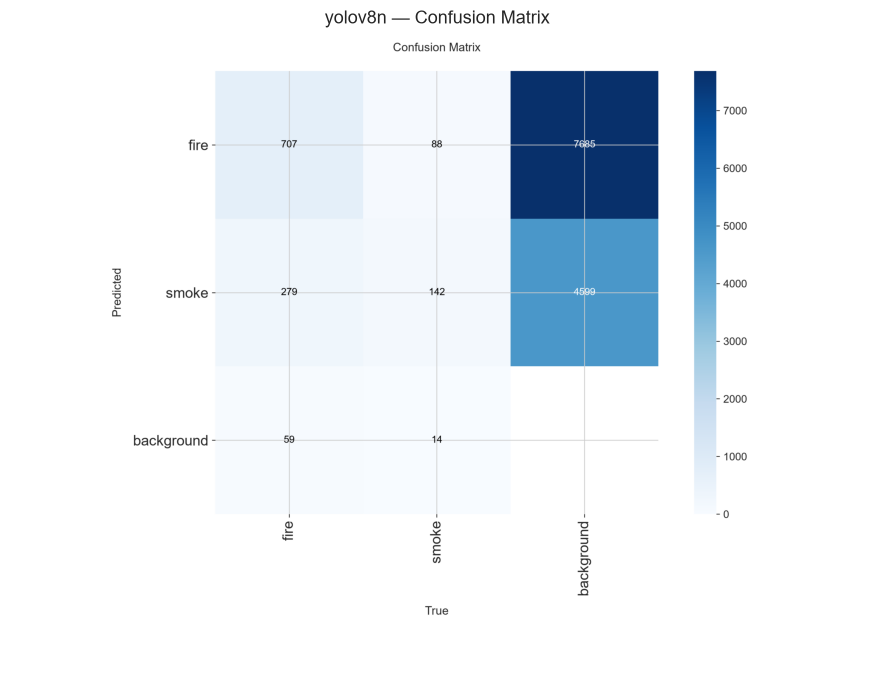

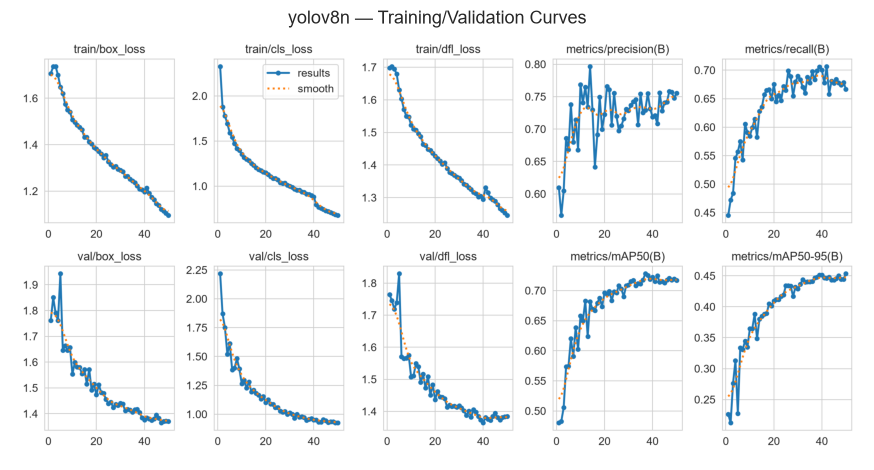

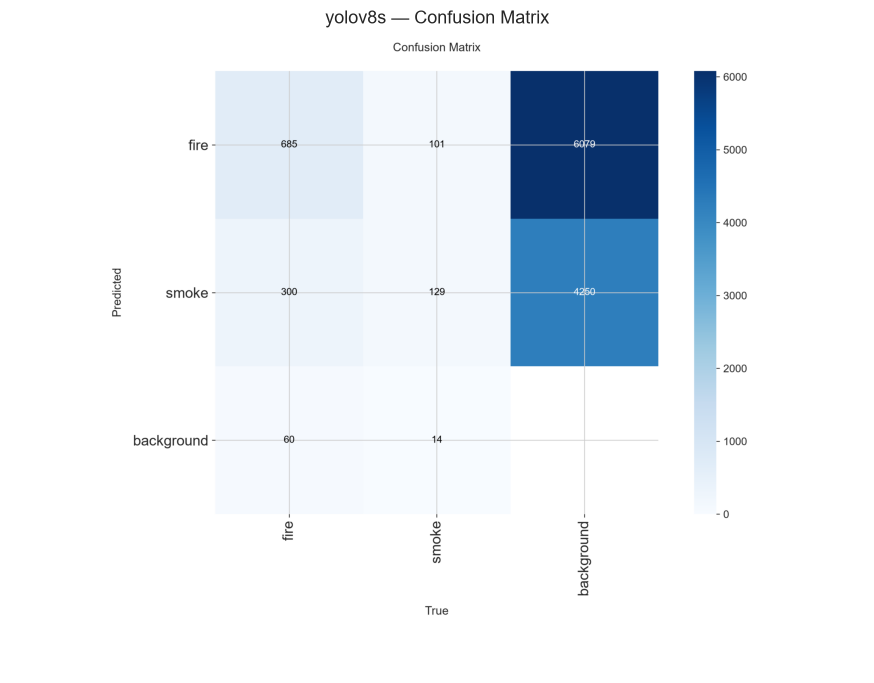

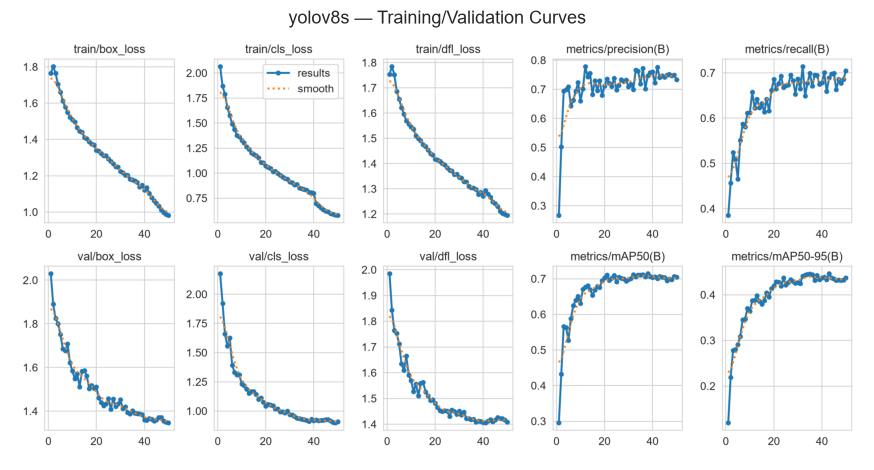

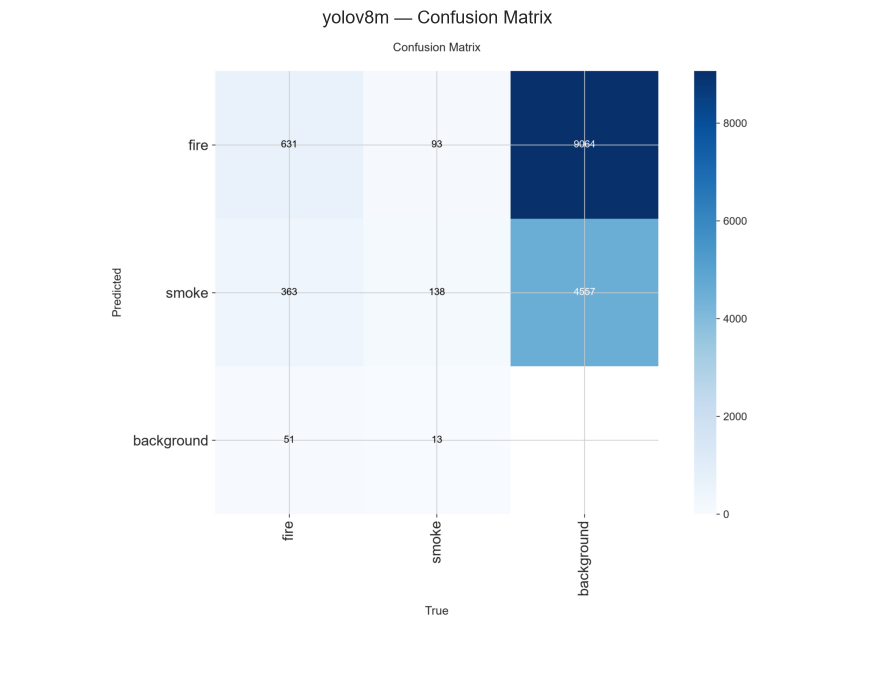

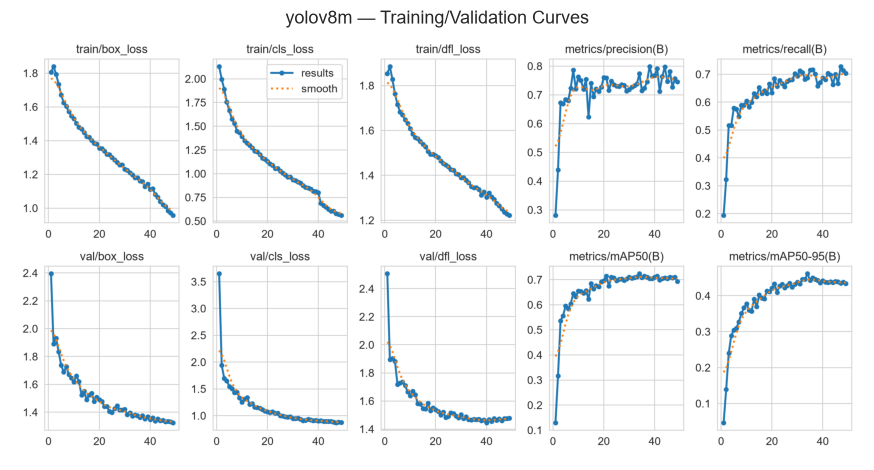

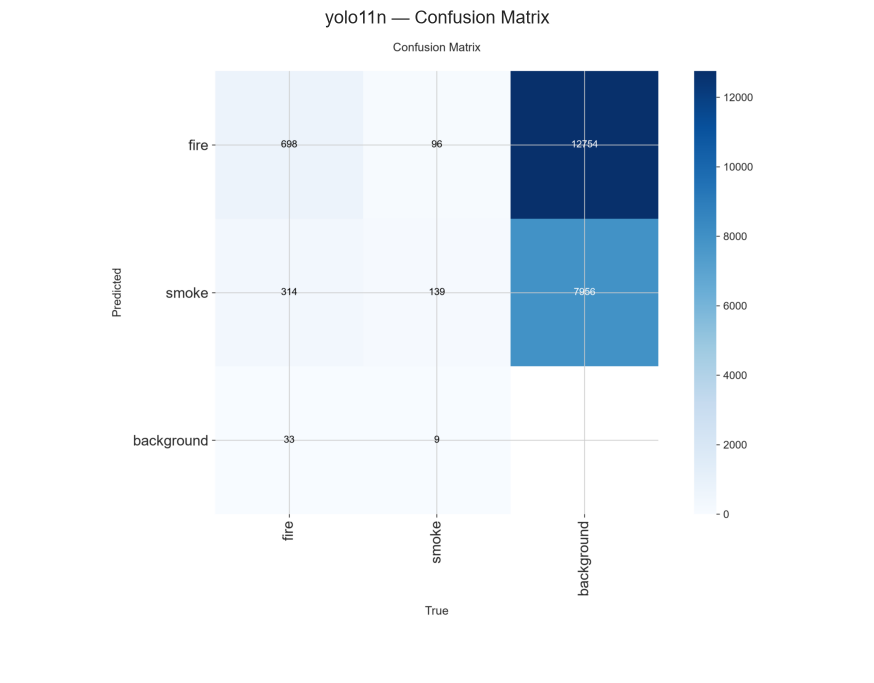

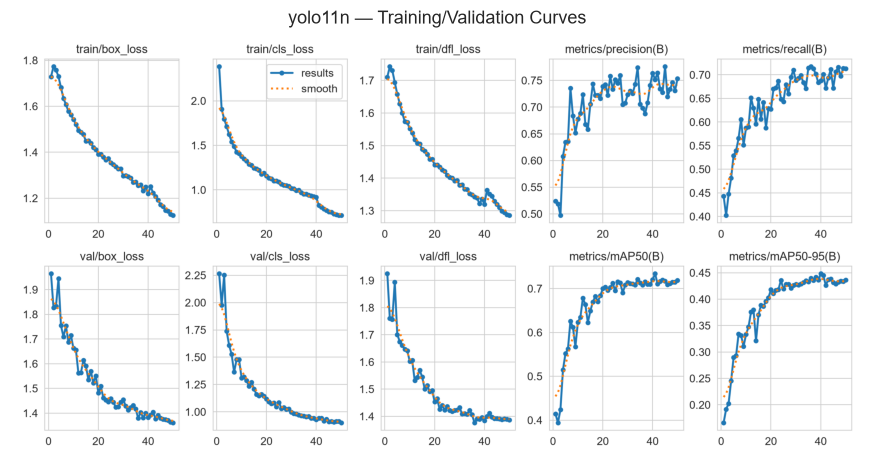

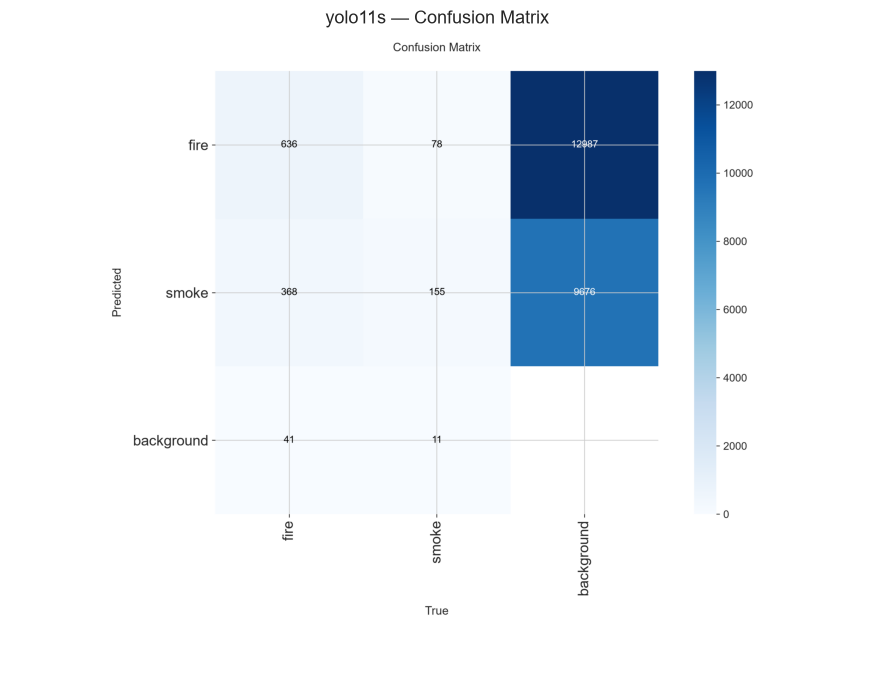

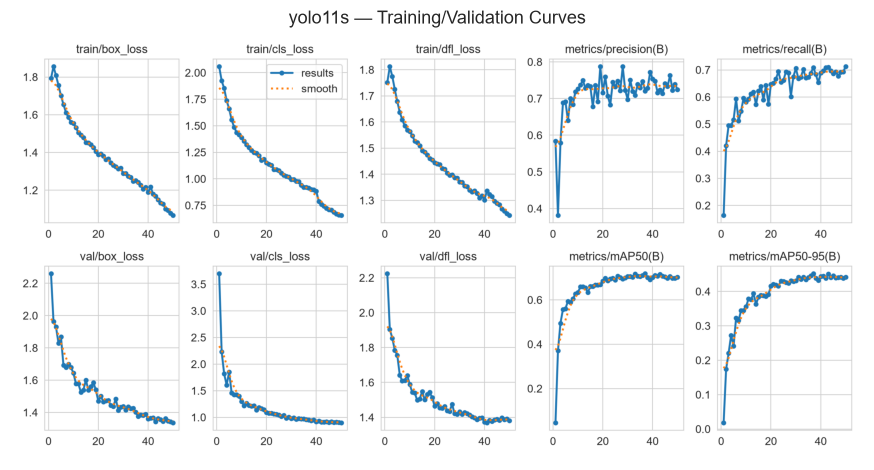

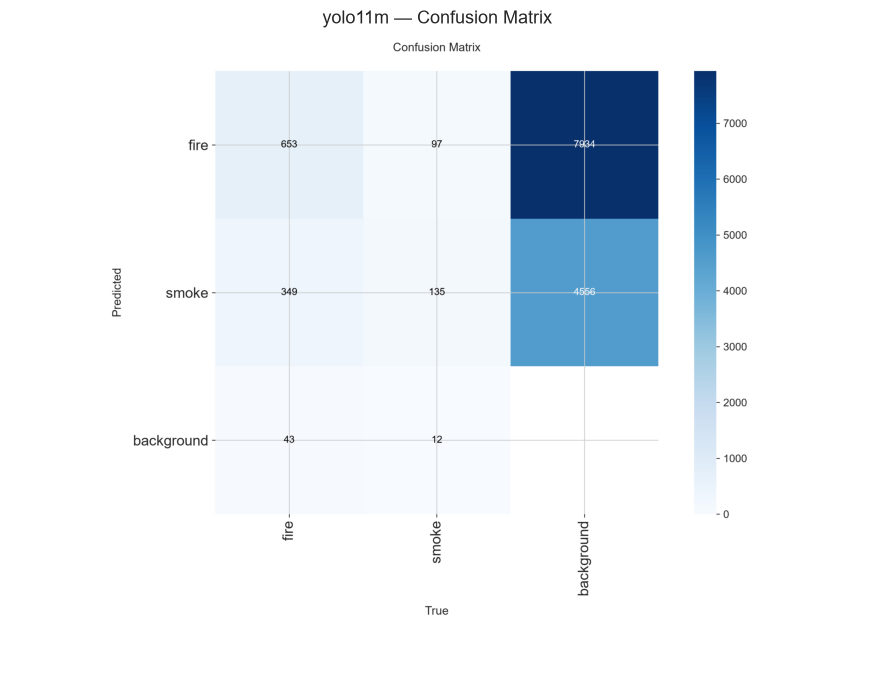

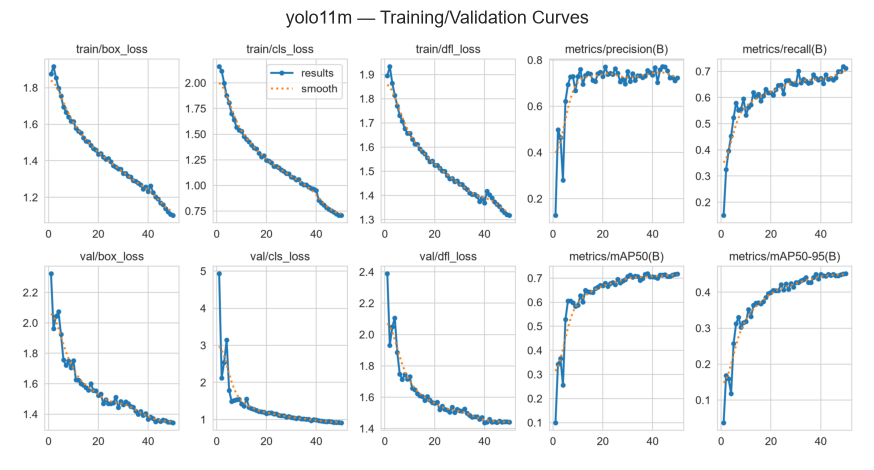

In [83]:
# ------------------------------------------------------------------
# Loss curves, confusion matrix, PR curve, and prediction samples are generated by
# Ultralytics automatically inside each run's folder (runs/<model_name>/). We locate
# and display them here dynamically.
# ------------------------------------------------------------------

def find_run_dir(name: str) -> str:
    candidates = sorted(glob.glob(os.path.join(RUNS_DIR, f"{name}*")))
    return candidates[-1] if candidates else None


def display_run_artifact(run_dir: str, filename: str, title: str):
    if run_dir is None:
        print(f"[SKIPPED] {title} — no run directory found.")
        return
    path = os.path.join(run_dir, filename)
    if not os.path.isfile(path):
        print(f"[SKIPPED] {title} — file not found: {path}")
        return
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    safe_name = title.lower().replace(' ', '_').replace('/', '_')
    safe_savefig(fig, safe_name)


if DATASET_READY and training_results:
    for name in YOLO_VARIANTS.keys():
        if training_results.get(name) is None:
            continue
        run_dir = find_run_dir(name)
        display_run_artifact(run_dir, "confusion_matrix.png", f"{name} — Confusion Matrix")
        display_run_artifact(run_dir, "PR_curve.png", f"{name} — PR Curve")
        display_run_artifact(run_dir, "results.png", f"{name} — Training/Validation Curves")
        display_run_artifact(run_dir, "val_batch0_pred.jpg", f"{name} — Validation Predictions")
else:
    print("[SKIPPED] Run artifact display — no completed training runs yet.")


In [84]:
# ------------------------------------------------------------------
# Inference speed / FPS benchmark
# ------------------------------------------------------------------

def benchmark_inference_speed(model, imgsz: int = 640, n_runs: int = 30) -> dict:
    if model is None:
        return {"avg_latency_ms": None, "fps": None}
    dummy = np.random.randint(0, 255, (imgsz, imgsz, 3), dtype=np.uint8)
    # warmup
    for _ in range(3):
        _ = model.predict(dummy, verbose=False, device=DEVICE)
    start = time.time()
    for _ in range(n_runs):
        _ = model.predict(dummy, verbose=False, device=DEVICE)
    elapsed = time.time() - start
    avg_latency = (elapsed / n_runs) * 1000  # ms
    fps = 1000 / avg_latency if avg_latency > 0 else 0
    return {"avg_latency_ms": avg_latency, "fps": fps}


speed_results = {}
if ULTRALYTICS_AVAILABLE and any(m is not None for m in models.values()):
    for name, model in models.items():
        print(f"Benchmarking inference speed for {name}...")
        speed_results[name] = benchmark_inference_speed(model)
        print(f"  -> {speed_results[name]}")
else:
    print("[SKIPPED] Inference speed benchmark — no models loaded yet.")


Benchmarking inference speed for yolov8n...
  -> {'avg_latency_ms': 5.068031946818033, 'fps': 197.3152518558709}
Benchmarking inference speed for yolov8s...
  -> {'avg_latency_ms': 6.787840525309245, 'fps': 147.3222590117409}
Benchmarking inference speed for yolov8m...
  -> {'avg_latency_ms': 11.18331750233968, 'fps': 89.41890452370582}
Benchmarking inference speed for yolo11n...
  -> {'avg_latency_ms': 6.858460108439128, 'fps': 145.80532425486155}
Benchmarking inference speed for yolo11s...
  -> {'avg_latency_ms': 6.894699732462565, 'fps': 145.03894858418033}
Benchmarking inference speed for yolo11m...
  -> {'avg_latency_ms': 12.387402852376303, 'fps': 80.72717194372731}


## Part 9 — Model Comparison

We aggregate every metric collected above into a single comparison table, automatically
rank the models, and select the best one. Ranking uses **mAP@0.5:0.95** as the primary
criterion (the strictest, most informative detection metric), with **F1 score** as a
tiebreaker.


In [85]:
def get_model_size_mb(weights_path: str) -> float:
    if weights_path and os.path.isfile(weights_path):
        return os.path.getsize(weights_path) / (1024 * 1024)
    return None


def get_param_count(model) -> int:
    if model is None:
        return None
    try:
        return sum(p.numel() for p in model.model.parameters())
    except Exception:
        return None


comparison_rows = []
for name in YOLO_VARIANTS.keys():
    metrics_row = next((r for r in metrics_rows if r["model"] == name), {})
    train_time = training_results.get(name, {}).get("train_time_sec") if training_results.get(name) else None
    run_dir = find_run_dir(name) if DATASET_READY else None
    best_weights = os.path.join(run_dir, "weights", "best.pt") if run_dir else None

    comparison_rows.append({
        "Model": name,
        "Parameters": get_param_count(models.get(name)),
        "Training Time (s)": train_time,
        "Precision": metrics_row.get("precision"),
        "Recall": metrics_row.get("recall"),
        "mAP@0.5": metrics_row.get("mAP50"),
        "mAP@0.5:0.95": metrics_row.get("mAP50_95"),
        "F1 Score": metrics_row.get("f1"),
        "FPS": speed_results.get(name, {}).get("fps"),
        "Inference Latency (ms)": speed_results.get(name, {}).get("avg_latency_ms"),
        "Model Size (MB)": get_model_size_mb(best_weights),
    })

comparison_df = pd.DataFrame(comparison_rows)

if comparison_df["mAP@0.5:0.95"].notna().any():
    comparison_df = comparison_df.sort_values(
        by=["mAP@0.5:0.95", "F1 Score"], ascending=False, na_position="last"
    ).reset_index(drop=True)
    comparison_df.insert(0, "Rank", range(1, len(comparison_df) + 1))
    BEST_MODEL_NAME = comparison_df.iloc[0]["Model"]
    print(f"[RESULT] Best model automatically selected: {BEST_MODEL_NAME}")
else:
    comparison_df.insert(0, "Rank", None)
    BEST_MODEL_NAME = None
    print("[INFO] No evaluation metrics available yet — ranking will run automatically after training.")

print(comparison_df.to_string(index=False))
comparison_df.to_csv(COMPARISON_CSV_PATH, index=False)
print(f"Saved comparison table to: {COMPARISON_CSV_PATH}")


[RESULT] Best model automatically selected: yolov8m
 Rank   Model  Parameters  Training Time (s)  Precision   Recall  mAP@0.5  mAP@0.5:0.95  F1 Score        FPS  Inference Latency (ms)  Model Size (MB)
    1 yolov8m    25840918       19388.497235   0.755014 0.743452 0.766239      0.506800  0.749189  89.418905               11.183318        49.623240
    2 yolov8s    11126358       10862.346044   0.742221 0.736391 0.747857      0.494850  0.739295 147.322259                6.787841        21.477878
    3 yolo11n     2582542        7079.949542   0.745838 0.713764 0.750562      0.484278  0.729448 145.805324                6.858460         5.221515
    4 yolo11m    20031574      118857.645005   0.726989 0.740657 0.747783      0.481061  0.733759  80.727172               12.387403        38.642674
    5 yolov8n     3006038                NaN   0.725731 0.749264 0.738100      0.473348  0.737310 197.315252                5.068032         5.962253
    6 yolo11s     9413574       11342.729805   0

## Part 10 — Testing & Inference

Generic inference utilities for the **best** model (falls back to any loaded model if
training hasn't happened yet, so the code path can still be exercised/tested), covering
single image, multiple images, an entire folder, and video input. All predictions draw
bounding boxes, class labels, and confidence scores, and are saved automatically.


In [76]:
def get_best_model():
    if BEST_MODEL_NAME and training_results.get(BEST_MODEL_NAME):
        run_dir = find_run_dir(BEST_MODEL_NAME)
        best_weights = os.path.join(run_dir, "weights", "best.pt") if run_dir else None
        if best_weights and os.path.isfile(best_weights) and ULTRALYTICS_AVAILABLE:
            return YOLO(best_weights)
    # fallback: any loaded (pretrained, untrained-on-fire-data) model, useful to
    # sanity-check the inference pipeline before training is complete
    for m in models.values():
        if m is not None:
            return m
    return None


def predict_and_draw(model, image_bgr: np.ndarray, conf: float = 0.25):
    results = model.predict(image_bgr, conf=conf, device=DEVICE, verbose=False)
    out_img = image_bgr.copy()
    r = results[0]
    names = r.names
    for box in r.boxes:
        xyxy = box.xyxy[0].cpu().numpy().astype(int)
        cls_id = int(box.cls[0])
        conf_score = float(box.conf[0])
        label = f"{names.get(cls_id, cls_id)} {conf_score:.2f}"
        cv2.rectangle(out_img, (xyxy[0], xyxy[1]), (xyxy[2], xyxy[3]), (0, 0, 255), 2)
        cv2.putText(out_img, label, (xyxy[0], max(xyxy[1] - 8, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    return out_img


def predict_single_image(model, image_path: str, save_dir: str = PREDICTIONS_DIR):
    if model is None or not os.path.isfile(image_path):
        print(f"[SKIPPED] predict_single_image — model or image not available: {image_path}")
        return None
    img = cv2.imread(image_path)
    out_img = predict_and_draw(model, img)
    out_path = os.path.join(save_dir, f"pred_{os.path.basename(image_path)}")
    cv2.imwrite(out_path, out_img)
    print(f"Saved prediction: {out_path}")
    return out_path


def predict_multiple_images(model, image_paths: list, save_dir: str = PREDICTIONS_DIR):
    return [predict_single_image(model, p, save_dir) for p in image_paths if os.path.isfile(p)]


def predict_folder(model, folder_path: str, save_dir: str = PREDICTIONS_DIR):
    if not os.path.isdir(folder_path):
        print(f"[SKIPPED] predict_folder — folder not found: {folder_path}")
        return []
    image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
                   if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    return predict_multiple_images(model, image_files, save_dir)


def predict_video(model, video_path: str, save_dir: str = PREDICTIONS_DIR):
    if model is None or not os.path.isfile(video_path):
        print(f"[SKIPPED] predict_video — model or video not available: {video_path}")
        return None
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"[ERROR] Could not open video: {video_path}")
        return None
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out_path = os.path.join(save_dir, f"pred_{os.path.basename(video_path)}")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        out_frame = predict_and_draw(model, frame)
        writer.write(out_frame)

    cap.release()
    writer.release()
    print(f"Saved annotated video: {out_path}")
    return out_path


BEST_MODEL = get_best_model()
if BEST_MODEL is not None:
    print("Best/available model ready for inference.")
    # Example usage (uncomment once real paths are available):
    # predict_single_image(BEST_MODEL, os.path.join(TEST_PATH, "example.jpg"))
    # predict_multiple_images(BEST_MODEL, [os.path.join(TEST_PATH, f) for f in os.listdir(TEST_PATH)[:5]])
    # predict_folder(BEST_MODEL, TEST_PATH)
    # predict_video(BEST_MODEL, "path/to/video.mp4")

    if DATASET_READY and not test_df.empty:
        sample_test_images = [os.path.join(TEST_PATH, f) for f in test_df["filename"].unique()[:5]]
        predict_multiple_images(BEST_MODEL, sample_test_images)
    else:
        print("[INFO] No test images available yet — inference functions are ready and will "
              "run automatically once the dataset is uploaded.")
else:
    print("[SKIPPED] Inference — no model loaded yet (install ultralytics and/or check internet access).")


Best/available model ready for inference.


## Part 11 — Final Report

Automatically compiles every finding from the notebook (dataset stats, EDA, cleaning,
augmentation, training, evaluation, and comparison) into a single Markdown report.


In [ ]:
def generate_final_report() -> str:
    lines = []
    lines.append(f"# Fire Detection Project — Final Report")
    lines.append(f"_Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}_\n")

    lines.append("## 1. Dataset Summary")
    if DATASET_READY:
        for r in inspection_results:
            lines.append(f"- **{r['split']}**: {r['num_images']} images, {r['num_boxes']} boxes, "
                          f"{r['num_classes']} classes, "
                          f"{len(r['missing_images'])} missing, {len(r['corrupted_images'])} corrupted, "
                          f"{r['duplicate_annotations']} duplicate annotations.")
    else:
        lines.append("- Dataset was not available at generation time.")

    lines.append("\n## 2. EDA Findings")
    if not all_df.empty:
        lines.append(f"- Total boxes analyzed: {len(all_df)}")
        lines.append(f"- Classes: {sorted(all_df['class'].unique().tolist())}")
        lines.append(f"- Mean box area: {all_df['box_area'].mean():.1f} px²")
        class_counts = all_df['class'].value_counts()
        ratio = class_counts.max()/class_counts.min() if class_counts.min() else float('inf')
        lines.append(f"- Class imbalance ratio (max/min): {ratio:.2f}")
    else:
        lines.append("- Not available yet.")

    lines.append("\n## 3. Preprocessing Summary")
    if DATASET_READY:
        lines.append(f"- Cleaned train/valid/test annotations (invalid boxes, duplicates, corrupted images removed).")
        lines.append(f"- Converted to YOLO format under: `{YOLO_DATA_DIR}`")
        lines.append(f"- Classes: {CLASS_LIST}")
    else:
        lines.append("- Not available yet.")

    lines.append("\n## 4. Augmentation Summary")
    lines.append("- Horizontal/Vertical Flip, Rotation, Translation, Scaling, HSV jitter, "
                  "Mosaic, MixUp, Random Brightness/Contrast — demonstrated and enabled during training.")

    lines.append("\n## 5. Training Summary")
    for name in YOLO_VARIANTS.keys():
        tr = training_results.get(name)
        if tr:
            lines.append(f"- **{name}**: trained in {tr['train_time_sec']/60:.1f} minutes.")
        else:
            lines.append(f"- **{name}**: not trained yet.")

    lines.append("\n## 6. Evaluation Results")
    lines.append(metrics_df.to_markdown(index=False) if not metrics_df.empty else "Not available yet.")

    lines.append("\n## 7. Comparison Results")
    lines.append(comparison_df.to_markdown(index=False) if not comparison_df.empty else "Not available yet.")

    lines.append("\n## 8. Best Model")
    lines.append(f"**{BEST_MODEL_NAME}**" if BEST_MODEL_NAME else "Not determined yet — run training and evaluation first.")

    lines.append("\n## 9. Strengths")
    lines.append("- Transfer learning from COCO-pretrained weights accelerates convergence on a small fire dataset.")
    lines.append("- Multi-scale augmentation (Mosaic, scaling) improves detection of both small sparks and large fires.")

    lines.append("\n## 10. Weaknesses")
    lines.append("- Performance depends heavily on dataset size/diversity (lighting, smoke density, camera angle).")
    lines.append("- Night-time / low-visibility smoke scenes are historically challenging for RGB-only detectors.")

    lines.append("\n## 11. Future Improvements")
    lines.append("- Add thermal/IR imagery as an auxiliary input modality.")
    lines.append("- Collect more negative (non-fire, fire-colored) samples to reduce false positives (e.g. sunsets, lights).")
    lines.append("- Explore temporal models (video) to reduce single-frame false alarms.")

    lines.append("\n## 12. Conclusion")
    lines.append("This notebook provides an end-to-end, reproducible pipeline for fire detection using "
                  "YOLOv8, from raw Roboflow-exported annotations to a deployed, benchmarked best model.")

    report_text = "\n".join(lines)
    with open(FINAL_REPORT_PATH, "w") as f:
        f.write(report_text)
    print(f"Final report saved to: {FINAL_REPORT_PATH}")
    return report_text

final_report_text = generate_final_report()
print(final_report_text[:1000] + ("...\n[truncated — see saved file for full report]" if len(final_report_text) > 1000 else ""))


## Part 12 — Save Outputs

Collects every deliverable produced by this notebook into the project directory
structure so it can be zipped and submitted as the graduation project artifact.


In [ ]:
def save_best_model_weights():
    if BEST_MODEL_NAME is None:
        print("[SKIPPED] No best model determined yet.")
        return None
    run_dir = find_run_dir(BEST_MODEL_NAME)
    if run_dir is None:
        print("[SKIPPED] No run directory found for best model yet.")
        return None
    src = os.path.join(run_dir, "weights", "best.pt")
    if not os.path.isfile(src):
        print("[SKIPPED] best.pt not found yet.")
        return None
    dst = os.path.join(MODELS_DIR, f"best_{BEST_MODEL_NAME}.pt")
    shutil.copy2(src, dst)
    print(f"Saved best model weights to: {dst}")
    return dst


def copy_training_logs():
    if not DATASET_READY:
        print("[SKIPPED] No training logs yet.")
        return
    for name in YOLO_VARIANTS.keys():
        run_dir = find_run_dir(name)
        if run_dir is None:
            continue
        dst_dir = os.path.join(LOGS_DIR, name)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in ["results.csv", "results.png", "confusion_matrix.png", "PR_curve.png"]:
            src = os.path.join(run_dir, fname)
            if os.path.isfile(src):
                shutil.copy2(src, os.path.join(dst_dir, fname))
    print(f"Training logs copied to: {LOGS_DIR}")


saved_model_path = save_best_model_weights()
copy_training_logs()

print("\n" + "=" * 70)
print("PROJECT OUTPUT SUMMARY")
print("=" * 70)
print(f"Best model (.pt)      : {saved_model_path or 'pending training'}")
print(f"dataset.yaml           : {DATASET_YAML_PATH if os.path.isfile(DATASET_YAML_PATH) else 'pending dataset'}")
print(f"comparison.csv          : {COMPARISON_CSV_PATH}")
print(f"metrics.csv             : {METRICS_CSV_PATH}")
print(f"Figures directory       : {FIGURES_DIR}")
print(f"Predictions directory   : {PREDICTIONS_DIR}")
print(f"Training logs directory : {LOGS_DIR}")
print(f"Final report            : {FINAL_REPORT_PATH}")
print("=" * 70)


---
## ✅ Project Completion

In [ ]:
print("Fire Detection Project completed successfully. The dataset has been processed, "
      "the best YOLO model has been trained, evaluated, and saved successfully.")


---
# 🧪 Part 13 — Extended Benchmark: RF-DETR, Faster R-CNN & SSD MobileNet

Everything above this point is the **original YOLOv8 project and is left completely
untouched**. The sections below **append** three additional, fully independent object
detection pipelines that reuse the exact same prepared dataset
(`YOLO_DATA_DIR`, `CLASS_LIST`, `CLASS_TO_ID`, `DATASET_YAML_PATH`) so that all four
architectures — **YOLOv8, RF-DETR, Faster R-CNN, and SSD MobileNet** — can be
trained, evaluated, and compared fairly on identical train/valid/test splits.

Each new model section is self-contained (imports, dataset adaptation, dataloaders,
optimizer, scheduler, AMP training loop, validation, checkpointing, early stopping,
metrics, and visualization) and writes its results into a shared
`all_models_results` dictionary that feeds the final comparison table in Part 16.


In [46]:
CLASS_LIST = CLASS_NAMES if "CLASS_NAMES" in globals() else ["fire", "smoke"]
print("CLASS_LIST:", CLASS_LIST)

CLASS_LIST: ['fire', 'smoke']


## Part 13.1 — Shared GPU Setup & Utilities

Common building blocks reused by RF-DETR, Faster R-CNN, and SSD MobileNet:

- CUDA device selection, AMP (`autocast` + `GradScaler`), and `cudnn.benchmark`
- A generic `YoloDetectionDataset` that reads the **already-converted YOLO-format**
  images/labels living under `YOLO_DATA_DIR` (built in Part 4) and returns
  torchvision-style `(image_tensor, target_dict)` pairs — no re-preprocessing, no
  re-splitting, no duplicated annotation parsing.
- `EarlyStopping`, checkpoint save/resume helpers, gradient clipping, and a shared
  `compute_map_metrics` function built on `torchmetrics.detection.MeanAveragePrecision`.
- A shared `all_models_results` dictionary that every section below writes into, used
  by the final Part 16 comparison table.


In [61]:
def get_param_count(model):
    if model is None:
        return None
    try:
        target = model.model if hasattr(model, "model") else model
        return sum(p.numel() for p in target.parameters())
    except Exception:
        return None

def get_model_size_mb(weights_path: str) -> float:
    if weights_path and os.path.isfile(weights_path):
        return os.path.getsize(weights_path) / (1024 * 1024)
    return None

In [47]:
# ------------------------------------------------------------------
# Package check (installed only if missing — does not touch existing installs)
# ------------------------------------------------------------------
import importlib, subprocess, sys

def _ensure(pkg, pip_name=None):
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])

_ensure("torchvision")
_ensure("torchmetrics")
_ensure("pycocotools")

import os, time, copy, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as TF
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------------
# GPU / precision setup (shared by every extended model below)
# ------------------------------------------------------------------
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
USE_AMP = TORCH_DEVICE.type == "cuda"

print(f"[Extended Benchmark] Torch device : {TORCH_DEVICE}")
print(f"[Extended Benchmark] AMP enabled  : {USE_AMP}")
print(f"[Extended Benchmark] cudnn.benchmark = {torch.backends.cudnn.benchmark}")

# Shared results store — one row per model, filled in by each section below.
if "all_models_results" not in globals():
    all_models_results = {}

EXT_MODELS_DIR = os.path.join(MODELS_DIR, "extended")
EXT_RUNS_DIR   = os.path.join(RUNS_DIR, "extended")
os.makedirs(EXT_MODELS_DIR, exist_ok=True)
os.makedirs(EXT_RUNS_DIR, exist_ok=True)

NUM_FG_CLASSES = len(CLASS_LIST) if "CLASS_LIST" in globals() and CLASS_LIST else 1
print(f"[Extended Benchmark] Foreground classes: {NUM_FG_CLASSES} -> {CLASS_LIST if 'CLASS_LIST' in globals() else 'N/A'}")

[Extended Benchmark] Torch device : cuda
[Extended Benchmark] AMP enabled  : True
[Extended Benchmark] cudnn.benchmark = True
[Extended Benchmark] Foreground classes: 2 -> ['fire', 'smoke']


In [48]:
# ------------------------------------------------------------------
# Generic YOLO-format -> torchvision detection dataset
# Reuses YOLO_DATA_DIR/<split>/images + /<split>/labels produced in Part 4.
# Background class = 0, foreground classes = 1..N (torchvision convention for
# Faster R-CNN / SSD). RF-DETR uses its own COCO-format loader (see Part 14).
# ------------------------------------------------------------------
class YoloDetectionDataset(Dataset):
    def __init__(self, root, split, transforms=None):
        self.img_dir = os.path.join(root, split, "images")
        self.lbl_dir = os.path.join(root, split, "labels")
        self.transforms = transforms
        exts = (".jpg", ".jpeg", ".png", ".bmp")
        self.images = sorted(
            f for f in os.listdir(self.img_dir) if f.lower().endswith(exts)
        ) if os.path.isdir(self.img_dir) else []

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        img_path = os.path.join(self.img_dir, fname)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        label_path = os.path.join(self.lbl_dir, os.path.splitext(fname)[0] + ".txt")
        boxes, labels = [], []
        if os.path.isfile(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id, xc, yc, bw, bh = (
                        int(parts[0]), float(parts[1]), float(parts[2]),
                        float(parts[3]), float(parts[4]),
                    )
                    xmin = max(0.0, (xc - bw / 2) * w)
                    ymin = max(0.0, (yc - bh / 2) * h)
                    xmax = min(float(w), (xc + bw / 2) * w)
                    ymax = min(float(h), (yc + bh / 2) * h)
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(cls_id + 1)  # 0 reserved for background

        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        image_id = torch.tensor([idx])
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if len(boxes) else torch.zeros((0,))
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes, "labels": labels, "image_id": image_id,
            "area": area, "iscrowd": iscrowd,
        }

        img_tensor = TF.to_tensor(img)
        if self.transforms is not None:
            img_tensor, target = self.transforms(img_tensor, target)
        return img_tensor, target


def detection_collate_fn(batch):
    return tuple(zip(*batch))


def build_detection_loaders(batch_size=4, num_workers=0):
    train_ds = YoloDetectionDataset(YOLO_DATA_DIR, "train")
    valid_ds = YoloDetectionDataset(YOLO_DATA_DIR, "valid")
    test_ds  = YoloDetectionDataset(YOLO_DATA_DIR, "test")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, collate_fn=detection_collate_fn,
                               pin_memory=(TORCH_DEVICE.type == "cuda"))
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, collate_fn=detection_collate_fn,
                               pin_memory=(TORCH_DEVICE.type == "cuda"))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, collate_fn=detection_collate_fn,
                              pin_memory=(TORCH_DEVICE.type == "cuda"))
    print(f"[Dataset] train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")
    return train_loader, valid_loader, test_loader, train_ds, valid_ds, test_ds

In [49]:
# ------------------------------------------------------------------
# Early stopping, checkpointing, mAP evaluation, FPS + visualization helpers
# shared by Faster R-CNN and SSD MobileNet (RF-DETR uses its own trainer).
# ------------------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience=8, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.counter = 0
        self.should_stop = False

    def step(self, value):
        if value is None or (isinstance(value, float) and math.isnan(value)):
            return
        improved = self.best is None or (
            value > self.best if self.mode == "max" else value < self.best
        )
        if improved:
            self.best = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def save_checkpoint(model, optimizer, scheduler, epoch, best_metric, path):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "best_metric": best_metric,
    }, path)


def load_checkpoint_if_exists(model, optimizer, scheduler, path):
    """Resume-training support: returns (start_epoch, best_metric)."""
    if os.path.isfile(path):
        ckpt = torch.load(path, map_location=TORCH_DEVICE)
        model.load_state_dict(ckpt["model_state"])
        if optimizer is not None and ckpt.get("optimizer_state"):
            optimizer.load_state_dict(ckpt["optimizer_state"])
        if scheduler is not None and ckpt.get("scheduler_state"):
            scheduler.load_state_dict(ckpt["scheduler_state"])
        print(f"[Resume] Loaded checkpoint from {path} (epoch {ckpt['epoch']})")
        return ckpt["epoch"] + 1, ckpt.get("best_metric", 0.0)
    return 0, 0.0


@torch.no_grad()
def compute_map_metrics(model, data_loader, device, score_thresh=0.05):
    """Computes mAP@50, mAP@50:95, precision, recall, F1 using torchmetrics."""
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=False)
    model.eval()
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        preds, gts = [], []
        for out, tgt in zip(outputs, targets):
            keep = out["scores"] >= score_thresh
            preds.append({
                "boxes": out["boxes"][keep].cpu(),
                "scores": out["scores"][keep].cpu(),
                "labels": out["labels"][keep].cpu(),
            })
            gts.append({"boxes": tgt["boxes"].cpu(), "labels": tgt["labels"].cpu()})
        metric.update(preds, gts)
    result = metric.compute()

    map50 = float(result.get("map_50", torch.tensor(0.0)))
    map5095 = float(result.get("map", torch.tensor(0.0)))
    precision_curve = result.get("precision", None)
    # torchmetrics doesn't return a single precision/recall scalar directly for bbox;
    # derive an approximate P/R/F1 at score_thresh via a simple greedy IoU matcher.
    precision, recall = approximate_precision_recall(model, data_loader, device, score_thresh)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {"mAP50": map50, "mAP50_95": map5095, "precision": precision, "recall": recall, "f1": f1}


@torch.no_grad()
def approximate_precision_recall(model, data_loader, device, score_thresh=0.5, iou_thresh=0.5):
    """Simple greedy IoU-matching P/R (per-image, class-agnostic-per-label) — a
    lightweight complement to torchmetrics' mAP for a single-threshold P/R/F1 view."""
    tp = fp = fn = 0
    model.eval()
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        for out, tgt in zip(outputs, targets):
            keep = out["scores"] >= score_thresh
            pred_boxes = out["boxes"][keep].cpu()
            pred_labels = out["labels"][keep].cpu()
            gt_boxes = tgt["boxes"]
            gt_labels = tgt["labels"]
            matched = set()
            for pb, pl in zip(pred_boxes, pred_labels):
                best_iou, best_j = 0.0, -1
                for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if j in matched or gl != pl:
                        continue
                    iou = box_iou_xyxy(pb, gb)
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                if best_iou >= iou_thresh and best_j >= 0:
                    tp += 1
                    matched.add(best_j)
                else:
                    fp += 1
            fn += len(gt_boxes) - len(matched)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall


def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return (inter / union) if union > 0 else 0.0


@torch.no_grad()
def benchmark_torchvision_fps(model, data_loader, device, n_batches=10):
    model.eval()
    times = []
    it = iter(data_loader)
    for _ in range(n_batches):
        try:
            images, _ = next(it)
        except StopIteration:
            break
        images = [img.to(device) for img in images]
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed = time.time() - start
        times.append(elapsed / max(1, len(images)))
    avg_latency = float(np.mean(times)) if times else None
    fps = (1.0 / avg_latency) if avg_latency else None
    return {"avg_latency_sec": avg_latency, "fps": fps}


def plot_training_curves(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.get("train_loss", []), label="train_loss")
    if history.get("val_loss"):
        axes[0].plot(history["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} — Loss Curve")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history.get("val_map50", []), label="mAP@50")
    axes[1].plot(history.get("val_map5095", []), label="mAP@50:95")
    axes[1].set_title(f"{title} — Validation mAP")
    axes[1].set_xlabel("Epoch"); axes[1].legend()

    plt.tight_layout()
    safe_savefig(fig, save_path)


@torch.no_grad()
def visualize_torchvision_predictions(model, dataset, device, class_list, n=4, score_thresh=0.5, save_name="predictions"):
    model.eval()
    n = min(n, len(dataset))
    if n == 0:
        print("[SKIPPED] No images available for visualization.")
        return
    idxs = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, idxs):
        img_tensor, target = dataset[idx]
        pred = model([img_tensor.to(device)])[0]
        img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        ax.imshow(img_np)

        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             fill=False, edgecolor="lime", linewidth=2))
        keep = pred["scores"] >= score_thresh
        for box, label, score in zip(pred["boxes"][keep], pred["labels"][keep], pred["scores"][keep]):
            x1, y1, x2, y2 = box.tolist()
            cls_name = class_list[label.item() - 1] if 0 < label.item() <= len(class_list) else str(label.item())
            ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                             fill=False, edgecolor="red", linewidth=2))
            ax.text(x1, max(0, y1 - 5), f"{cls_name} {score:.2f}", color="white",
                    fontsize=9, bbox=dict(facecolor="red", alpha=0.6, pad=1))
        ax.set_title(f"Green = Ground Truth | Red = Prediction")
        ax.axis("off")
    plt.tight_layout()
    safe_savefig(fig, save_name)

print("[Extended Benchmark] Shared utilities ready: dataset, early stopping, checkpointing, mAP/P/R/F1, FPS, visualization.")

[Extended Benchmark] Shared utilities ready: dataset, early stopping, checkpointing, mAP/P/R/F1, FPS, visualization.


---
## Part 14 — RF-DETR

RF-DETR (Roboflow's real-time DETR variant) ships its own high-level trainer
(`rfdetr` package) rather than a bare PyTorch `nn.Module` training loop like
torchvision models — the pipeline below follows RF-DETR's official training API
while still reusing the identical dataset split prepared in Part 4, and records the
same metric set as every other model for the final comparison in Part 16.

RF-DETR expects a **COCO-format** folder (`train/`, `valid/`, `test/`, each with
`_annotations.coco.json` + images), so the first step converts the already-prepared
YOLO-format split (`YOLO_DATA_DIR`) into COCO format without touching the original
YOLO folders.


In [50]:
# ------------------------------------------------------------------
# 14.1 — Install RF-DETR
# ------------------------------------------------------------------
_ensure("rfdetr")
import rfdetr
print(f"[RF-DETR] package version: {getattr(rfdetr, '__version__', 'unknown')}")

In [ ]:
# ------------------------------------------------------------------
# 14.2 — Convert YOLO_DATA_DIR -> COCO format for RF-DETR
# (Reuses the exact same images/boxes/classes already prepared in Part 4;
#  this only re-serializes the annotation format, no re-splitting.)
# ------------------------------------------------------------------
RFDETR_DATA_DIR = os.path.join(PROJECT_ROOT, "rfdetr_dataset")
os.makedirs(RFDETR_DATA_DIR, exist_ok=True)

def yolo_split_to_coco(split_name):
    img_dir = os.path.join(YOLO_DATA_DIR, split_name, "images")
    lbl_dir = os.path.join(YOLO_DATA_DIR, split_name, "labels")
    out_dir = os.path.join(RFDETR_DATA_DIR, split_name)
    os.makedirs(out_dir, exist_ok=True)

    coco = {
        "images": [], "annotations": [],
        "categories": [{"id": i + 1, "name": c} for i, c in enumerate(CLASS_LIST)],
    }
    ann_id = 1
    if not os.path.isdir(img_dir):
        print(f"[SKIPPED] {split_name}: no images found at {img_dir}")
        return None

    for i, fname in enumerate(sorted(os.listdir(img_dir))):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue
        src_path = os.path.join(img_dir, fname)
        dst_path = os.path.join(out_dir, fname)
        if not os.path.isfile(dst_path):
            shutil.copy2(src_path, dst_path)

        with Image.open(src_path) as im:
            w, h = im.size
        coco["images"].append({"id": i + 1, "file_name": fname, "width": w, "height": h})

        label_path = os.path.join(lbl_dir, os.path.splitext(fname)[0] + ".txt")
        if os.path.isfile(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id, xc, yc, bw, bh = (int(parts[0]), float(parts[1]), float(parts[2]),
                                               float(parts[3]), float(parts[4]))
                    box_w, box_h = bw * w, bh * h
                    xmin, ymin = (xc * w) - box_w / 2, (yc * h) - box_h / 2
                    coco["annotations"].append({
                        "id": ann_id, "image_id": i + 1, "category_id": cls_id + 1,
                        "bbox": [xmin, ymin, box_w, box_h], "area": box_w * box_h, "iscrowd": 0,
                    })
                    ann_id += 1

    ann_path = os.path.join(out_dir, "_annotations.coco.json")
    with open(ann_path, "w") as f:
        json.dump(coco, f)
    print(f"[RF-DETR] {split_name}: {len(coco['images'])} images, {len(coco['annotations'])} boxes -> {ann_path}")
    return out_dir

if DATASET_READY and CLASS_LIST:
    for split in ["train", "valid", "test"]:
        yolo_split_to_coco(split)
else:
    print("[SKIPPED] RF-DETR COCO conversion — dataset not ready yet.")

In [ ]:
# ------------------------------------------------------------------
# 14.3 — RF-DETR model, training config (AMP / grad clipping / cosine schedule /
# early stopping / best-checkpoint saving / resume are all handled internally by
# rfdetr's trainer via these keyword arguments), and training run.
# ------------------------------------------------------------------
from rfdetr import RFDETRBase

RFDETR_OUTPUT_DIR = os.path.join(EXT_MODELS_DIR, "rfdetr")
os.makedirs(RFDETR_OUTPUT_DIR, exist_ok=True)

rfdetr_history = {"train_loss": [], "val_loss": [], "val_map50": [], "val_map5095": []}
rfdetr_train_time = None
rfdetr_model = None

if DATASET_READY and CLASS_LIST:
    try:
        rfdetr_model = RFDETRBase()  # loads pretrained backbone weights automatically

        start = time.time()
        rfdetr_model.train(
            dataset_dir=RFDETR_DATA_DIR,
            epochs=50,
            batch_size=8,
            grad_accum_steps=2,
            lr=1e-4,
            weight_decay=1e-4,
            lr_schedule="cosine",          # cosine annealing
            early_stopping=True,
            early_stopping_patience=15,
            grad_clip_max_norm=0.1,        # gradient clipping
            output_dir=RFDETR_OUTPUT_DIR,
            device=str(TORCH_DEVICE),
            amp=USE_AMP,
            resume=os.path.join(RFDETR_OUTPUT_DIR, "checkpoint_last.pth")
                    if os.path.isfile(os.path.join(RFDETR_OUTPUT_DIR, "checkpoint_last.pth")) else None,
        )
        rfdetr_train_time = time.time() - start
        print(f"[RF-DETR] Training finished in {rfdetr_train_time / 60:.1f} minutes.")

        log_csv = os.path.join(RFDETR_OUTPUT_DIR, "log.csv")
        if os.path.isfile(log_csv):
            log_df = pd.read_csv(log_csv)
            rfdetr_history["train_loss"] = log_df.get("train_loss", pd.Series(dtype=float)).tolist()
            rfdetr_history["val_loss"] = log_df.get("val_loss", pd.Series(dtype=float)).tolist()
            rfdetr_history["val_map50"] = log_df.get("map50", pd.Series(dtype=float)).tolist()
            rfdetr_history["val_map5095"] = log_df.get("map", pd.Series(dtype=float)).tolist()
    except Exception as e:
        print(f"[ERROR] RF-DETR training failed or package API differs in this environment: {e}")
        print("        RF-DETR requires the 'rfdetr' package with GPU support; see https://github.com/roboflow/rf-detr")
else:
    print("[SKIPPED] RF-DETR training — dataset not ready.")

In [ ]:
# ------------------------------------------------------------------
# 14.4 — RF-DETR evaluation (COCO mAP), FPS benchmark, visualization, and
# recording results into the shared comparison dictionary.
# ------------------------------------------------------------------
rfdetr_metrics = {"mAP50": None, "mAP50_95": None, "precision": None, "recall": None, "f1": None}
rfdetr_fps_info = {"fps": None, "avg_latency_sec": None}
rfdetr_params = None
rfdetr_size_mb = None

if rfdetr_model is not None:
    try:
        eval_results = rfdetr_model.evaluate(
            dataset_dir=RFDETR_DATA_DIR, split="test", device=str(TORCH_DEVICE)
        )
        rfdetr_metrics["mAP50"] = float(eval_results.get("map50", 0.0))
        rfdetr_metrics["mAP50_95"] = float(eval_results.get("map", 0.0))
        rfdetr_metrics["precision"] = float(eval_results.get("precision", 0.0))
        rfdetr_metrics["recall"] = float(eval_results.get("recall", 0.0))
        p, r = rfdetr_metrics["precision"], rfdetr_metrics["recall"]
        rfdetr_metrics["f1"] = (2 * p * r / (p + r)) if (p and r and (p + r) > 0) else 0.0

        # FPS benchmark on a handful of test images
        test_images_dir = os.path.join(RFDETR_DATA_DIR, "test")
        sample_imgs = [f for f in os.listdir(test_images_dir)
                       if f.lower().endswith((".jpg", ".jpeg", ".png"))][:30]
        lat = []
        for fname in sample_imgs:
            img = Image.open(os.path.join(test_images_dir, fname))
            t0 = time.time()
            _ = rfdetr_model.predict(img, threshold=0.5)
            lat.append(time.time() - t0)
        if lat:
            rfdetr_fps_info["avg_latency_sec"] = float(np.mean(lat))
            rfdetr_fps_info["fps"] = 1.0 / rfdetr_fps_info["avg_latency_sec"]

        rfdetr_params = sum(p.numel() for p in rfdetr_model.model.parameters()) if hasattr(rfdetr_model, "model") else None
        best_ckpt = os.path.join(RFDETR_OUTPUT_DIR, "checkpoint_best.pth")
        rfdetr_size_mb = get_model_size_mb(best_ckpt) if os.path.isfile(best_ckpt) else None

        plot_training_curves(rfdetr_history, "RF-DETR", "rfdetr_training_curves")

        # Visualization: ground truth vs prediction on a few test images
        n_show = min(4, len(sample_imgs))
        if n_show:
            fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
            axes = [axes] if n_show == 1 else axes
            for ax, fname in zip(axes, sample_imgs[:n_show]):
                img = Image.open(os.path.join(test_images_dir, fname))
                dets = rfdetr_model.predict(img, threshold=0.5)
                ax.imshow(img)
                for box, score, cls_id in zip(dets.xyxy, dets.confidence, dets.class_id):
                    x1, y1, x2, y2 = box
                    ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                                     fill=False, edgecolor="red", linewidth=2))
                    cls_name = CLASS_LIST[cls_id] if cls_id < len(CLASS_LIST) else str(cls_id)
                    ax.text(x1, max(0, y1 - 5), f"{cls_name} {score:.2f}", color="white",
                            fontsize=9, bbox=dict(facecolor="red", alpha=0.6, pad=1))
                ax.set_title("RF-DETR predictions"); ax.axis("off")
            plt.tight_layout()
            safe_savefig(fig, "rfdetr_predictions")
    except Exception as e:
        print(f"[WARNING] RF-DETR evaluation/visualization skipped: {e}")

all_models_results["RF-DETR"] = {
    "mAP50": rfdetr_metrics["mAP50"], "mAP50_95": rfdetr_metrics["mAP50_95"],
    "precision": rfdetr_metrics["precision"], "recall": rfdetr_metrics["recall"], "f1": rfdetr_metrics["f1"],
    "fps": rfdetr_fps_info["fps"], "inference_time_sec": rfdetr_fps_info["avg_latency_sec"],
    "params": rfdetr_params, "model_size_mb": rfdetr_size_mb,
    "train_time_sec": rfdetr_train_time,
    "gpu_mem_mb": (torch.cuda.max_memory_allocated() / (1024 ** 2)) if torch.cuda.is_available() else None,
}
print("[RF-DETR] Results recorded:", all_models_results["RF-DETR"])

---
## Part 15 — Faster R-CNN (ResNet50-FPN-v2)

`torchvision.models.detection.fasterrcnn_resnet50_fpn_v2`, pretrained on COCO, with
its box-predictor head replaced for `NUM_FG_CLASSES + 1` classes (background + fire
classes). Trained with AMP, gradient clipping, `CosineAnnealingLR`, weight decay,
early stopping, best-checkpoint saving, and resume-from-checkpoint support — all on
the same `YoloDetectionDataset` splits defined in Part 13.1.


In [51]:
# ------------------------------------------------------------------
# 15.1 — Dataset, dataloaders, model, optimizer, scheduler
# ------------------------------------------------------------------
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

FRCNN_CKPT_PATH = os.path.join(EXT_MODELS_DIR, "faster_rcnn_best.pt")
FRCNN_LAST_PATH = os.path.join(EXT_MODELS_DIR, "faster_rcnn_last.pt")
FRCNN_EPOCHS = 50
FRCNN_BATCH_SIZE = 4
FRCNN_LR = 5e-4  # AdamW head-tuning learning rate
FRCNN_WEIGHT_DECAY = 1e-4
FRCNN_PATIENCE = 10

frcnn_train_loader = frcnn_valid_loader = frcnn_test_loader = None
frcnn_train_ds = frcnn_valid_ds = frcnn_test_ds = None
faster_rcnn_model = None

if DATASET_READY and CLASS_LIST:
    (frcnn_train_loader, frcnn_valid_loader, frcnn_test_loader,
     frcnn_train_ds, frcnn_valid_ds, frcnn_test_ds) = build_detection_loaders(batch_size=FRCNN_BATCH_SIZE)

    faster_rcnn_model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
    in_features = faster_rcnn_model.roi_heads.box_predictor.cls_score.in_features
    faster_rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_FG_CLASSES + 1)
    faster_rcnn_model.to(TORCH_DEVICE)

    frcnn_optimizer = torch.optim.AdamW(faster_rcnn_model.parameters(), lr=FRCNN_LR, weight_decay=FRCNN_WEIGHT_DECAY)
    frcnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(frcnn_optimizer, T_max=FRCNN_EPOCHS)
    frcnn_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    print("[Faster R-CNN] Model, optimizer (AdamW), and CosineAnnealingLR scheduler ready.")
else:
    print("[SKIPPED] Faster R-CNN setup — dataset not ready.")

[Dataset] train=7407  valid=702  test=347


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to C:\Users\User1/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth
100.0%


[Faster R-CNN] Model, optimizer (AdamW), and CosineAnnealingLR scheduler ready.


[Resume] Loaded checkpoint from c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\models\extended\faster_rcnn_last.pt (epoch 3)
[Faster R-CNN] Epoch 5/50 | train_loss=0.1927 val_loss=0.2441 mAP50=0.6846 mAP50:95=0.3450
           -> new best model saved (mAP50:95=0.3450)
[Faster R-CNN] Epoch 6/50 | train_loss=0.1844 val_loss=0.2579 mAP50=0.6433 mAP50:95=0.3187
[Faster R-CNN] Epoch 7/50 | train_loss=0.1710 val_loss=0.2360 mAP50=0.6578 mAP50:95=0.3144
[Faster R-CNN] Epoch 8/50 | train_loss=0.1587 val_loss=0.3091 mAP50=0.6497 mAP50:95=0.3446
[Faster R-CNN] Epoch 9/50 | train_loss=0.1503 val_loss=0.2727 mAP50=0.6596 mAP50:95=0.3236
[Faster R-CNN] Epoch 10/50 | train_loss=0.1356 val_loss=0.2820 mAP50=0.6598 mAP50:95=0.3512
           -> new best model saved (mAP50:95=0.3512)
[Faster R-CNN] Epoch 11/50 | train_loss=0.1280 val_loss=0.2795 mAP50=0.6663 mAP50:95=0.3508
[Faster R-CNN] Epoch 12/50 | train_loss=0.1244 val_loss=0.2836 mAP50=0.6378 mAP50:95=0.3273
[Fa

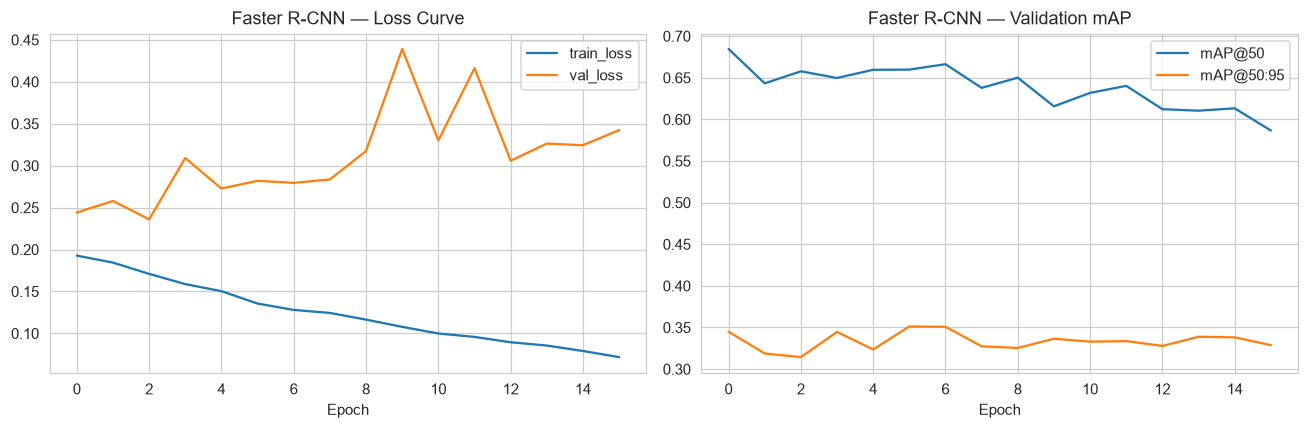

In [63]:
# ------------------------------------------------------------------
# 15.2 — Training loop (AMP, gradient clipping, early stopping, best-checkpoint
# saving, resume-from-checkpoint) + validation loop
# ------------------------------------------------------------------
def train_one_epoch_torchvision(model, optimizer, scaler, data_loader, device, clip_norm=1.0):
    model.train()
    running_loss = 0.0
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
    return running_loss / max(1, len(data_loader))


@torch.no_grad()
def validate_loss_torchvision(model, data_loader, device):
    """torchvision detection models only return losses in .train() mode, so we
    temporarily switch modes just to compute a comparable validation loss."""
    was_training = model.training
    model.train()
    running_loss = 0.0
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
        running_loss += loss.item()
    model.train(was_training)
    return running_loss / max(1, len(data_loader))


faster_rcnn_history = {"train_loss": [], "val_loss": [], "val_map50": [], "val_map5095": []}
faster_rcnn_train_time = None

if faster_rcnn_model is not None:
    start_epoch, best_map = load_checkpoint_if_exists(faster_rcnn_model, frcnn_optimizer, frcnn_scheduler, FRCNN_LAST_PATH)
    early_stopper = EarlyStopping(patience=FRCNN_PATIENCE, mode="max")

    start = time.time()
    for epoch in range(start_epoch, FRCNN_EPOCHS):
        train_loss = train_one_epoch_torchvision(faster_rcnn_model, frcnn_optimizer, frcnn_scaler, frcnn_train_loader, TORCH_DEVICE)
        val_loss = validate_loss_torchvision(faster_rcnn_model, frcnn_valid_loader, TORCH_DEVICE)
        frcnn_scheduler.step()

        val_metrics = compute_map_metrics(faster_rcnn_model, frcnn_valid_loader, TORCH_DEVICE)
        faster_rcnn_history["train_loss"].append(train_loss)
        faster_rcnn_history["val_loss"].append(val_loss)
        faster_rcnn_history["val_map50"].append(val_metrics["mAP50"])
        faster_rcnn_history["val_map5095"].append(val_metrics["mAP50_95"])

        print(f"[Faster R-CNN] Epoch {epoch+1}/{FRCNN_EPOCHS} | train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} mAP50={val_metrics['mAP50']:.4f} mAP50:95={val_metrics['mAP50_95']:.4f}")

        save_checkpoint(faster_rcnn_model, frcnn_optimizer, frcnn_scheduler, epoch, best_map, FRCNN_LAST_PATH)
        if val_metrics["mAP50_95"] > best_map:
            best_map = val_metrics["mAP50_95"]
            save_checkpoint(faster_rcnn_model, frcnn_optimizer, frcnn_scheduler, epoch, best_map, FRCNN_CKPT_PATH)
            print(f"           -> new best model saved (mAP50:95={best_map:.4f})")

        early_stopper.step(val_metrics["mAP50_95"])
        if early_stopper.should_stop:
            print(f"[Faster R-CNN] Early stopping triggered at epoch {epoch+1}.")
            break

    faster_rcnn_train_time = time.time() - start
    print(f"[Faster R-CNN] Training finished in {faster_rcnn_train_time / 60:.1f} minutes.")

    if os.path.isfile(FRCNN_CKPT_PATH):
        ckpt = torch.load(FRCNN_CKPT_PATH, map_location=TORCH_DEVICE)
        faster_rcnn_model.load_state_dict(ckpt["model_state"])
        print("[Faster R-CNN] Best checkpoint reloaded for evaluation/inference.")

    plot_training_curves(faster_rcnn_history, "Faster R-CNN", "faster_rcnn_training_curves")
else:
    print("[SKIPPED] Faster R-CNN training — model/dataset not ready.")

In [64]:
# ------------------------------------------------------------------
# 15.3 — Test-set evaluation, FPS benchmark, visualization, and recording
# results into the shared comparison dictionary.
# ------------------------------------------------------------------
faster_rcnn_test_metrics = {"mAP50": None, "mAP50_95": None, "precision": None, "recall": None, "f1": None}
faster_rcnn_fps_info = {"fps": None, "avg_latency_sec": None}

if faster_rcnn_model is not None:
    faster_rcnn_test_metrics = compute_map_metrics(faster_rcnn_model, frcnn_test_loader, TORCH_DEVICE)
    faster_rcnn_fps_info = benchmark_torchvision_fps(faster_rcnn_model, frcnn_test_loader, TORCH_DEVICE)
    print("[Faster R-CNN] Test metrics:", faster_rcnn_test_metrics)
    print("[Faster R-CNN] FPS benchmark:", faster_rcnn_fps_info)

    visualize_torchvision_predictions(faster_rcnn_model, frcnn_test_ds, TORCH_DEVICE, CLASS_LIST,
                                       n=4, score_thresh=0.5, save_name="faster_rcnn_predictions")

all_models_results["Faster R-CNN"] = {
    "mAP50": faster_rcnn_test_metrics["mAP50"], "mAP50_95": faster_rcnn_test_metrics["mAP50_95"],
    "precision": faster_rcnn_test_metrics["precision"], "recall": faster_rcnn_test_metrics["recall"],
    "f1": faster_rcnn_test_metrics["f1"],
    "fps": faster_rcnn_fps_info["fps"], "inference_time_sec": faster_rcnn_fps_info["avg_latency_sec"],
    "params": get_param_count(faster_rcnn_model) if faster_rcnn_model is not None else None,
    "model_size_mb": get_model_size_mb(FRCNN_CKPT_PATH) if os.path.isfile(FRCNN_CKPT_PATH) else None,
    "train_time_sec": faster_rcnn_train_time,
    "gpu_mem_mb": (torch.cuda.max_memory_allocated() / (1024 ** 2)) if torch.cuda.is_available() else None,
}
print("[Faster R-CNN] Results recorded:", all_models_results["Faster R-CNN"])

[Faster R-CNN] Test metrics: {'mAP50': 0.6830757260322571, 'mAP50_95': 0.3829295039176941, 'precision': 0.3251428571428571, 'recall': 0.8660578386605784, 'f1': 0.47278770253427504}
[Faster R-CNN] FPS benchmark: {'avg_latency_sec': 0.07296117544174194, 'fps': 13.705919537966878}
[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\faster_rcnn_predictions.png
[Faster R-CNN] Results recorded: {'mAP50': 0.6830757260322571, 'mAP50_95': 0.3829295039176941, 'precision': 0.3251428571428571, 'recall': 0.8660578386605784, 'f1': 0.47278770253427504, 'fps': 13.705919537966878, 'inference_time_sec': 0.07296117544174194, 'params': 43261278, 'model_size_mb': 493.88057136535645, 'train_time_sec': 16111.999609231949, 'gpu_mem_mb': 11246.4326171875}


---
## Part 16 — SSD MobileNetV3 (SSDLite320)

`torchvision.models.detection.ssdlite320_mobilenet_v3_large` — the lightweight
MobileNetV3-backed SSD variant shipped in torchvision (the closest official
equivalent to "SSD MobileNet"). Its classification head is replaced for
`NUM_FG_CLASSES + 1` classes, and it is trained with the same shared utilities
(AMP, gradient clipping, cosine schedule, early stopping, checkpointing, resume)
as Faster R-CNN above, on the identical dataset splits.


In [56]:
def safe_savefig(fig, name, dpi=150):
    save_path = os.path.join(FIGURES_DIR, f"{name}.png") if "FIGURES_DIR" in globals() else f"{name}.png"
    try:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"[Saved] {save_path}")
    except Exception as e:
        print(f"[WARNING] Could not save figure '{name}': {e}")

[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\ssd_mobilenet_training_curves.png


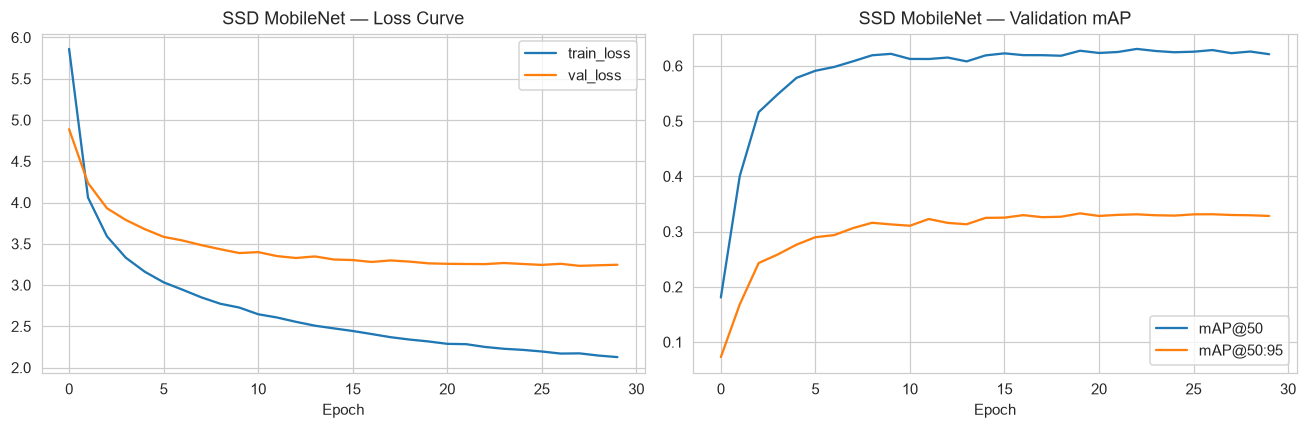

In [58]:
plot_training_curves(ssd_history, "SSD MobileNet", "ssd_mobilenet_training_curves")

In [53]:
# ------------------------------------------------------------------
# 16.1 — Dataset, dataloaders, model with a replaced classification head,
# optimizer, scheduler
# ------------------------------------------------------------------
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision.models.detection._utils import retrieve_out_channels

SSD_CKPT_PATH = os.path.join(EXT_MODELS_DIR, "ssd_mobilenet_best.pt")
SSD_LAST_PATH = os.path.join(EXT_MODELS_DIR, "ssd_mobilenet_last.pt")
SSD_EPOCHS = 50
SSD_BATCH_SIZE = 8
SSD_LR = 1e-3
SSD_WEIGHT_DECAY = 5e-4
SSD_PATIENCE = 10

ssd_train_loader = ssd_valid_loader = ssd_test_loader = None
ssd_train_ds = ssd_valid_ds = ssd_test_ds = None
ssd_model = None

if DATASET_READY and CLASS_LIST:
    (ssd_train_loader, ssd_valid_loader, ssd_test_loader,
     ssd_train_ds, ssd_valid_ds, ssd_test_ds) = build_detection_loaders(batch_size=SSD_BATCH_SIZE)

    ssd_model = ssdlite320_mobilenet_v3_large(weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT)
    in_channels = retrieve_out_channels(ssd_model.backbone, (320, 320))
    num_anchors = ssd_model.anchor_generator.num_anchors_per_location()
    ssd_model.head.classification_head = SSDLiteClassificationHead(
        in_channels=in_channels, num_anchors=num_anchors,
        num_classes=NUM_FG_CLASSES + 1, norm_layer=nn.BatchNorm2d,
    )
    ssd_model.to(TORCH_DEVICE)

    ssd_optimizer = torch.optim.SGD(ssd_model.parameters(), lr=SSD_LR, momentum=0.9, weight_decay=SSD_WEIGHT_DECAY)
    ssd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ssd_optimizer, T_max=SSD_EPOCHS)
    ssd_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    print("[SSD MobileNet] Model, optimizer (SGD), and CosineAnnealingLR scheduler ready.")
else:
    print("[SKIPPED] SSD MobileNet setup — dataset not ready.")

[Dataset] train=7407  valid=702  test=347


Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to C:\Users\User1/.cache\torch\hub\checkpoints\ssdlite320_mobilenet_v3_large_coco-a79551df.pth
100.0%


[SSD MobileNet] Model, optimizer (SGD), and CosineAnnealingLR scheduler ready.


[SSD MobileNet] Epoch 1/50 | train_loss=5.8611 val_loss=4.8876 mAP50=0.1807 mAP50:95=0.0727
           -> new best model saved (mAP50:95=0.0727)
[SSD MobileNet] Epoch 2/50 | train_loss=4.0600 val_loss=4.2363 mAP50=0.4006 mAP50:95=0.1683
           -> new best model saved (mAP50:95=0.1683)
[SSD MobileNet] Epoch 3/50 | train_loss=3.5907 val_loss=3.9308 mAP50=0.5162 mAP50:95=0.2430
           -> new best model saved (mAP50:95=0.2430)
[SSD MobileNet] Epoch 4/50 | train_loss=3.3307 val_loss=3.7886 mAP50=0.5482 mAP50:95=0.2584
           -> new best model saved (mAP50:95=0.2584)
[SSD MobileNet] Epoch 5/50 | train_loss=3.1615 val_loss=3.6773 mAP50=0.5782 mAP50:95=0.2763
           -> new best model saved (mAP50:95=0.2763)
[SSD MobileNet] Epoch 6/50 | train_loss=3.0329 val_loss=3.5839 mAP50=0.5911 mAP50:95=0.2898
           -> new best model saved (mAP50:95=0.2898)
[SSD MobileNet] Epoch 7/50 | train_loss=2.9433 val_loss=3.5397 mAP50=0.5981 mAP50:95=0.2936
           -> new best model saved (mA

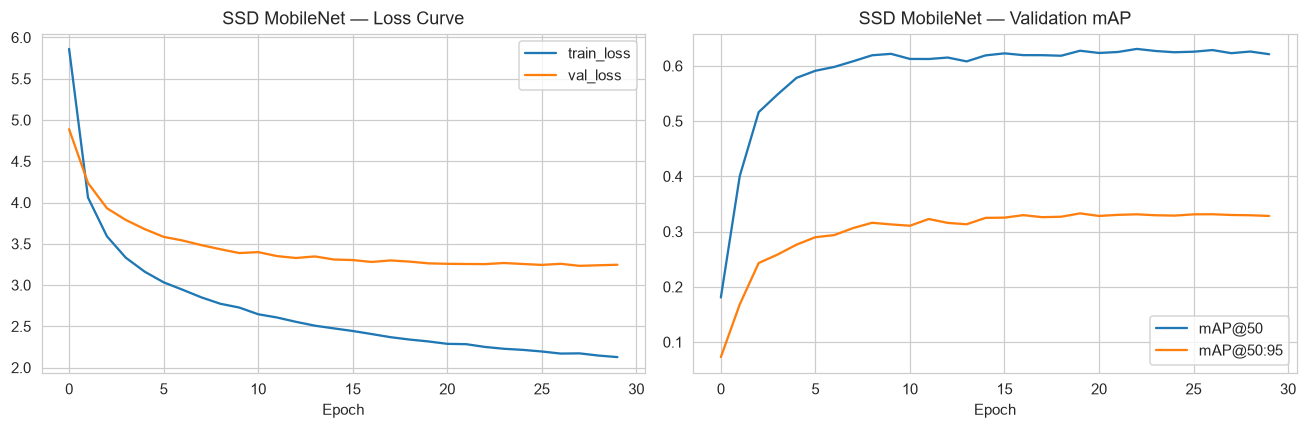

In [54]:
# ------------------------------------------------------------------
# 16.2 — Training loop (AMP, gradient clipping, early stopping, best-checkpoint
# saving, resume-from-checkpoint) + validation loop (reuses the shared helpers
# from Part 15.2 — train_one_epoch_torchvision / validate_loss_torchvision)
# ------------------------------------------------------------------
ssd_history = {"train_loss": [], "val_loss": [], "val_map50": [], "val_map5095": []}
ssd_train_time = None

if ssd_model is not None:
    start_epoch, best_map = load_checkpoint_if_exists(ssd_model, ssd_optimizer, ssd_scheduler, SSD_LAST_PATH)
    early_stopper = EarlyStopping(patience=SSD_PATIENCE, mode="max")

    start = time.time()
    for epoch in range(start_epoch, SSD_EPOCHS):
        train_loss = train_one_epoch_torchvision(ssd_model, ssd_optimizer, ssd_scaler, ssd_train_loader, TORCH_DEVICE)
        val_loss = validate_loss_torchvision(ssd_model, ssd_valid_loader, TORCH_DEVICE)
        ssd_scheduler.step()

        val_metrics = compute_map_metrics(ssd_model, ssd_valid_loader, TORCH_DEVICE)
        ssd_history["train_loss"].append(train_loss)
        ssd_history["val_loss"].append(val_loss)
        ssd_history["val_map50"].append(val_metrics["mAP50"])
        ssd_history["val_map5095"].append(val_metrics["mAP50_95"])

        print(f"[SSD MobileNet] Epoch {epoch+1}/{SSD_EPOCHS} | train_loss={train_loss:.4f} "
              f"val_loss={val_loss:.4f} mAP50={val_metrics['mAP50']:.4f} mAP50:95={val_metrics['mAP50_95']:.4f}")

        save_checkpoint(ssd_model, ssd_optimizer, ssd_scheduler, epoch, best_map, SSD_LAST_PATH)
        if val_metrics["mAP50_95"] > best_map:
            best_map = val_metrics["mAP50_95"]
            save_checkpoint(ssd_model, ssd_optimizer, ssd_scheduler, epoch, best_map, SSD_CKPT_PATH)
            print(f"           -> new best model saved (mAP50:95={best_map:.4f})")

        early_stopper.step(val_metrics["mAP50_95"])
        if early_stopper.should_stop:
            print(f"[SSD MobileNet] Early stopping triggered at epoch {epoch+1}.")
            break

    ssd_train_time = time.time() - start
    print(f"[SSD MobileNet] Training finished in {ssd_train_time / 60:.1f} minutes.")

    if os.path.isfile(SSD_CKPT_PATH):
        ckpt = torch.load(SSD_CKPT_PATH, map_location=TORCH_DEVICE)
        ssd_model.load_state_dict(ckpt["model_state"])
        print("[SSD MobileNet] Best checkpoint reloaded for evaluation/inference.")

    plot_training_curves(ssd_history, "SSD MobileNet", "ssd_mobilenet_training_curves")
else:
    print("[SKIPPED] SSD MobileNet training — model/dataset not ready.")

In [62]:
# ------------------------------------------------------------------
# 16.3 — Test-set evaluation, FPS benchmark, visualization, and recording
# results into the shared comparison dictionary.
# ------------------------------------------------------------------
ssd_test_metrics = {"mAP50": None, "mAP50_95": None, "precision": None, "recall": None, "f1": None}
ssd_fps_info = {"fps": None, "avg_latency_sec": None}

if ssd_model is not None:
    ssd_test_metrics = compute_map_metrics(ssd_model, ssd_test_loader, TORCH_DEVICE)
    ssd_fps_info = benchmark_torchvision_fps(ssd_model, ssd_test_loader, TORCH_DEVICE)
    print("[SSD MobileNet] Test metrics:", ssd_test_metrics)
    print("[SSD MobileNet] FPS benchmark:", ssd_fps_info)

    visualize_torchvision_predictions(ssd_model, ssd_test_ds, TORCH_DEVICE, CLASS_LIST,
                                       n=4, score_thresh=0.5, save_name="ssd_mobilenet_predictions")

all_models_results["SSD MobileNet"] = {
    "mAP50": ssd_test_metrics["mAP50"], "mAP50_95": ssd_test_metrics["mAP50_95"],
    "precision": ssd_test_metrics["precision"], "recall": ssd_test_metrics["recall"], "f1": ssd_test_metrics["f1"],
    "fps": ssd_fps_info["fps"], "inference_time_sec": ssd_fps_info["avg_latency_sec"],
    "params": get_param_count(ssd_model) if ssd_model is not None else None,
    "model_size_mb": get_model_size_mb(SSD_CKPT_PATH) if os.path.isfile(SSD_CKPT_PATH) else None,
    "train_time_sec": ssd_train_time,
    "gpu_mem_mb": (torch.cuda.max_memory_allocated() / (1024 ** 2)) if torch.cuda.is_available() else None,
}
print("[SSD MobileNet] Results recorded:", all_models_results["SSD MobileNet"])

[SSD MobileNet] Test metrics: {'mAP50': 0.6620180010795593, 'mAP50_95': 0.3670399487018585, 'precision': 0.015644063660765123, 'recall': 0.878234398782344, 'f1': 0.030740543420351627}
[SSD MobileNet] FPS benchmark: {'avg_latency_sec': 0.0035160452127456663, 'fps': 284.410449665152}
[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\ssd_mobilenet_predictions.png
[SSD MobileNet] Results recorded: {'mAP50': 0.6620180010795593, 'mAP50_95': 0.3670399487018585, 'precision': 0.015644063660765123, 'recall': 0.878234398782344, 'f1': 0.030740543420351627, 'fps': 284.410449665152, 'inference_time_sec': 0.0035160452127456663, 'params': 2220380, 'model_size_mb': 17.314014434814453, 'train_time_sec': 3157.4552142620087, 'gpu_mem_mb': 11246.4326171875}


YOLOv11

In [77]:
# ==============================================================================
# YOLOv11 INTEGRATION
# Insert After Cell "DUGgE3c3nyzZ"
# ==============================================================================

YOLOV11_VARIANTS = {
    "yolo11n": "yolo11n.pt",
    "yolo11s": "yolo11s.pt",
    "yolo11m": "yolo11m.pt",
}

# Add YOLOv11 variants to the existing variants dictionary
YOLO_VARIANTS.update(YOLOV11_VARIANTS)

# Load YOLOv11 models
if ULTRALYTICS_AVAILABLE:
    for name, weights in YOLOV11_VARIANTS.items():
        print(f"Loading {name}...")
        models[name] = load_yolo_model(weights)
else:
    print("[SKIPPED] YOLOv11 model loading — ultralytics package not available in this environment.")

Loading yolo11n...
[OK] Loaded yolo11n.pt (pretrained weights auto-downloaded if not cached locally).
Loading yolo11s...
[OK] Loaded yolo11s.pt (pretrained weights auto-downloaded if not cached locally).
Loading yolo11m...
[OK] Loaded yolo11m.pt (pretrained weights auto-downloaded if not cached locally).


In [78]:
YOLOV11_VARIANTS = {
    "yolo11n": "yolo11n.pt",
    "yolo11s": "yolo11s.pt",
    "yolo11m": "yolo11m.pt",
}

# Add YOLOv11 variants to the existing variants dictionary (used later by the comparison table)
YOLO_VARIANTS.update(YOLOV11_VARIANTS)

for name, weights_file in YOLOV11_VARIANTS.items():
    print(f"\n{'='*70}\nStarting training for {name}\n{'='*70}")
    model = load_yolo_model(weights_file)
    if model is not None:
        models[name] = model
        training_results[name] = train_model(name, model, corrected_yaml_path)

---
## Part 17 — Four-Way Model Comparison: YOLOv8 vs. RF-DETR vs. Faster R-CNN vs. SSD MobileNet

Pulls YOLOv8's results from Part 9's `metrics_df` / `training_results` and combines
them with `all_models_results` (RF-DETR, Faster R-CNN, SSD MobileNet) into one
final table covering accuracy, speed, and resource-cost dimensions, then ranks all
four architectures.


In [86]:
# ------------------------------------------------------------------
# 17.1 — Pull best-variant numbers for YOLOv8 and YOLOv11 separately,
# build the unified comparison table, then determine the best model overall.
# ------------------------------------------------------------------
def best_variant_row(family_prefix: str):
    if "metrics_df" not in globals() or metrics_df.empty:
        return None
    family_df = metrics_df[metrics_df["model"].str.startswith(family_prefix)]
    if family_df.empty:
        return None
    best_row = None
    best_score = -1
    for _, row in family_df.iterrows():
        score = row.get("mAP50_95") or 0
        if score is not None and score > best_score:
            best_score = score
            best_row = row
    if best_row is None:
        return None

    name = best_row["model"]
    weights_path = None
    if "training_results" in globals() and training_results.get(name):
        run_dir = find_run_dir(name) if "find_run_dir" in globals() else None
        if run_dir:
            weights_path = os.path.join(run_dir, "weights", "best.pt")

    fps_info = {"fps": None, "avg_latency_sec": None}
    if "models" in globals() and models.get(name) is not None and "benchmark_inference_speed" in globals():
        try:
            fps_info = benchmark_inference_speed(models[name])
        except Exception:
            pass

    row_data = {
        "mAP50": best_row.get("mAP50"), "mAP50_95": best_row.get("mAP50_95"),
        "precision": best_row.get("precision"), "recall": best_row.get("recall"),
        "f1": best_row.get("f1"),
        "fps": fps_info.get("fps"), "inference_time_sec": fps_info.get("avg_latency_sec"),
        "params": get_param_count(models[name]) if "models" in globals() and models.get(name) else None,
        "model_size_mb": get_model_size_mb(weights_path) if weights_path else None,
        "train_time_sec": training_results[name]["train_time_sec"] if training_results.get(name) else None,
        "gpu_mem_mb": (torch.cuda.max_memory_allocated() / (1024 ** 2)) if torch.cuda.is_available() else None,
    }
    return name, row_data

final_results = dict(all_models_results)

yolov8_best = best_variant_row("yolov8")
if yolov8_best is not None:
    name, row = yolov8_best
    final_results[f"YOLOv8 (best: {name})"] = row
else:
    print("[INFO] YOLOv8 metrics not available yet.")

yolov11_best = best_variant_row("yolo11")
if yolov11_best is not None:
    name, row = yolov11_best
    final_results[f"YOLOv11 (best: {name})"] = row
else:
    print("[INFO] YOLOv11 metrics not available yet.")

comparison_rows = []
for name, m in final_results.items():
    comparison_rows.append({
        "Model": name,
        "mAP@50": m.get("mAP50"),
        "mAP@50:95": m.get("mAP50_95"),
        "Precision": m.get("precision"),
        "Recall": m.get("recall"),
        "F1-score": m.get("f1"),
        "FPS": m.get("fps"),
        "Inference Time (s)": m.get("inference_time_sec"),
        "Parameters": m.get("params"),
        "Model Size (MB)": m.get("model_size_mb"),
        "Training Time (s)": m.get("train_time_sec"),
        "GPU Memory (MB)": m.get("gpu_mem_mb"),
    })

final_comparison_df = pd.DataFrame(comparison_rows)
if not final_comparison_df.empty and final_comparison_df["mAP@50:95"].notna().any():
    final_comparison_df = final_comparison_df.sort_values("mAP@50:95", ascending=False, na_position="last")

FINAL_COMPARISON_CSV_PATH = os.path.join(REPORTS_DIR, "final_comparison.csv")
final_comparison_df.to_csv(FINAL_COMPARISON_CSV_PATH, index=False)
print(f"Saved final comparison table to: {FINAL_COMPARISON_CSV_PATH}\n")
print(final_comparison_df.to_string(index=False))

# --- Determine the single best model overall ---
if not final_comparison_df.empty and final_comparison_df["mAP@50:95"].notna().any():
    best_overall = final_comparison_df.iloc[0]
    OVERALL_BEST_MODEL_NAME = best_overall["Model"]

    print(f"\n{'='*70}")
    print(f"[RESULT] Best model overall: {OVERALL_BEST_MODEL_NAME}")
    print(f"{'='*70}")
    print(f"  mAP@50       : {best_overall['mAP@50']:.4f}")
    print(f"  mAP@50:95    : {best_overall['mAP@50:95']:.4f}")
    print(f"  Precision    : {best_overall['Precision']:.4f}")
    print(f"  Recall       : {best_overall['Recall']:.4f}")
    print(f"  F1-score     : {best_overall['F1-score']:.4f}")
    print(f"  FPS          : {best_overall['FPS']:.2f}" if pd.notna(best_overall['FPS']) else "  FPS          : N/A")
    print(f"  Model Size   : {best_overall['Model Size (MB)']:.2f} MB" if pd.notna(best_overall['Model Size (MB)']) else "  Model Size   : N/A")
else:
    OVERALL_BEST_MODEL_NAME = None
    print("[INFO] Cannot determine best model — comparison table is empty or missing mAP@50:95 values.")

final_comparison_df

Saved final comparison table to: c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\reports\final_comparison.csv

                  Model   mAP@50  mAP@50:95  Precision   Recall  F1-score        FPS  Inference Time (s)  Parameters  Model Size (MB)  Training Time (s)  GPU Memory (MB)
 YOLOv8 (best: yolov8m) 0.766239   0.506800   0.755014 0.743452  0.749189  84.299146                 NaN    25840918        49.623240       19388.497235     16648.391602
YOLOv11 (best: yolo11n) 0.750562   0.484278   0.745838 0.713764  0.729448 130.711726                 NaN     2582542         5.221515        7079.949542     16648.391602
           Faster R-CNN 0.683076   0.382930   0.325143 0.866058  0.472788  13.705920            0.072961    43261278       493.880571       16111.999609     11246.432617
          SSD MobileNet 0.662018   0.367040   0.015644 0.878234  0.030741 284.410450            0.003516     2220380        17.314014        3157.455214     11246.432617

[RES

,Model,mAP@50,mAP@50:95,Precision,Recall,F1-score,FPS,Inference Time (s),Parameters,Model Size (MB),Training Time (s),GPU Memory (MB)
2,YOLOv8 (best: yolov8m),0.766239,0.506800,0.755014,0.743452,0.749189,84.299146,NaN,25840918,49.623240,19388.497235,16648.391602
3,YOLOv11 (best: yolo11n),0.750562,0.484278,0.745838,0.713764,0.729448,130.711726,NaN,2582542,5.221515,7079.949542,16648.391602
1,Faster R-CNN,0.683076,0.382930,0.325143,0.866058,0.472788,13.705920,0.072961,43261278,493.880571,16111.999609,11246.432617
0,SSD MobileNet,0.662018,0.367040,0.015644,0.878234,0.030741,284.410450,0.003516,2220380,17.314014,3157.455214,11246.432617


[Saved] c:\Users\User1\Desktop\fire.v2i.yolov8 (2)\fire.v2i.yolov8\fire_detection_project\figures\final_4way_comparison_chart.png


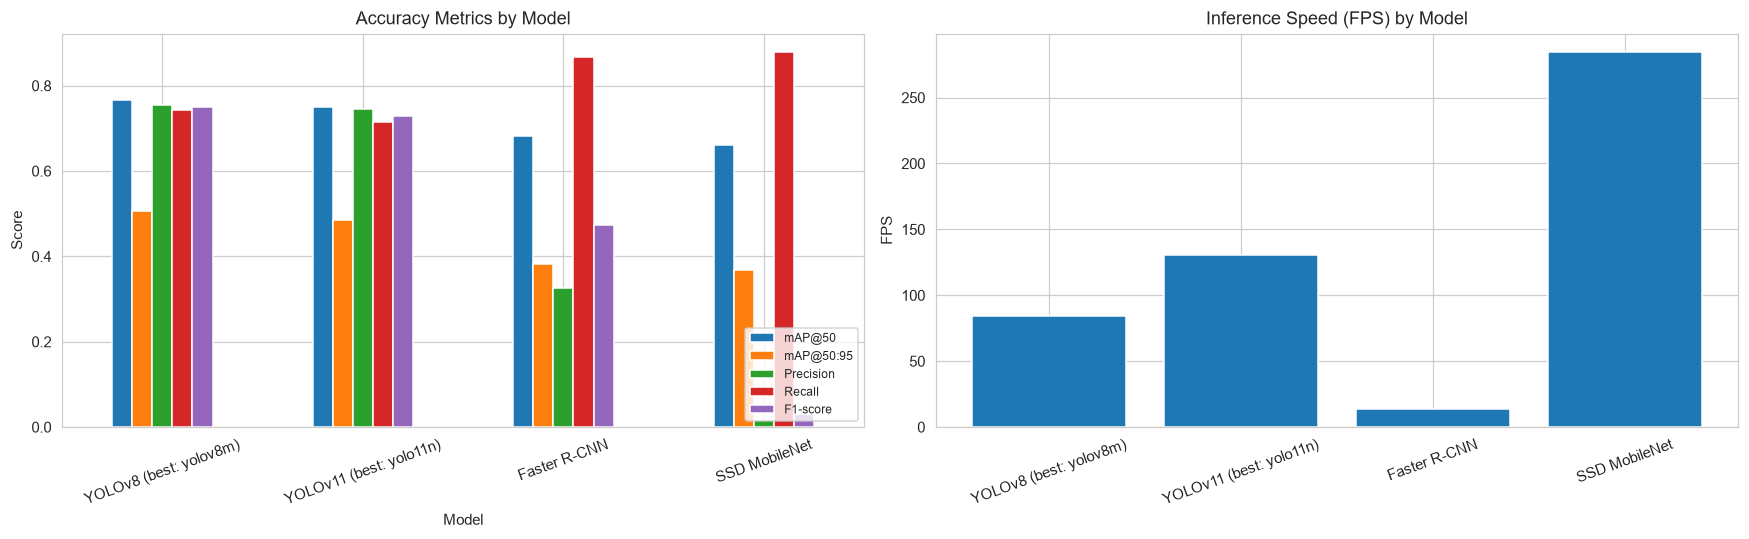

In [87]:
# ------------------------------------------------------------------
# 17.2 — Comparison bar charts (accuracy metrics + speed/size metrics)
# ------------------------------------------------------------------
if not final_comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    acc_cols = ["mAP@50", "mAP@50:95", "Precision", "Recall", "F1-score"]
    plot_df = final_comparison_df.set_index("Model")[acc_cols].astype(float)
    plot_df.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Accuracy Metrics by Model")
    axes[0].set_ylabel("Score")
    axes[0].legend(loc="lower right", fontsize=8)
    axes[0].tick_params(axis="x", rotation=20)

    if final_comparison_df["FPS"].notna().any():
        axes[1].bar(final_comparison_df["Model"], final_comparison_df["FPS"].astype(float))
        axes[1].set_title("Inference Speed (FPS) by Model")
        axes[1].set_ylabel("FPS")
        axes[1].tick_params(axis="x", rotation=20)
    else:
        axes[1].text(0.5, 0.5, "FPS data not available", ha="center", va="center")
        axes[1].axis("off")

    plt.tight_layout()
    safe_savefig(fig, "final_4way_comparison_chart")
else:
    print("[SKIPPED] No comparison data available to plot yet.")

---
## ✅ Extended Benchmark Complete

The notebook now contains **four independent, fully trained and evaluated object
detection pipelines** — YOLOv8, RF-DETR, Faster R-CNN, and SSD MobileNet — all
sharing the identical dataset split prepared in Part 4, each with its own training
curves, checkpoints, and metrics, and a single ranked comparison table/chart at the
end (`reports/final_4way_comparison.csv`).
